## Scratch Researh

In [1]:
print('This notebook was done for reserach from scratch !!!')

This notebook was done for reserach from scratch !!!


In [3]:
import pandas as pd

In [4]:
%pwd

'e:\\dsProject\\customerSegmentation\\research'

In [5]:
import os
os.chdir('../')

In [6]:
%pwd

'e:\\dsProject\\customerSegmentation'

In [7]:
pd.set_option('display.max_columns', 999)

__Core Methods to Score and Segment__
* Percentile/Quintile Ranking: Sort all customers from 1 to 5 for each metric. The top 20% get a 5, and the bottom 20% get a 1, creating combined scores like 5-5-5 for top champions.
* Cluster Analysis (K-Means): Use machine learning algorithms in Python or R to automatically cluster data points into natural groups based on similarity.
* Custom Thresholds/Decision Trees: Set manual business rules (e.g., Recency under 30 days = High) or decision trees to segment users based on your specific industry norms.

__What is RFM Analysis / segmentation?__

RFM stands for Recency, Frequency, and Monetary Value. These three factors provide valuable insights into customer behavior:


* Recency (R): This factor measures how recently a customer has interacted with your brand. It answers the question: How much time has elapsed since a customer’s last activity or transaction? A recent interaction indicates an active and engaged customer.
* Frequency (F): Frequency evaluates how often a customer engages with your product or service. It considers metrics such as login frequency, purchase frequency, or feature usage. Frequent interactions suggest strong brand loyalty.
* Monetary Value (M): Monetary value represents the total amount a customer has spent. High spending customers contribute more revenue to your business. It considers both individual transactions and overall lifetime value.

*Application of RFM Analysis / segmentation?*
* Segmentation: RFM helps businesses divide their customer base into homogeneous groups.
* Targeted Marketing: RFM helps Businesses to understand the needs of each segment and tailor marketing strategies aroud established needs.
* Retention and Loyalty: Recency affects customer retention, while frequency and monetary value impact loyalty. Businesses can use this information to cultivate strong loyalty.
* Improve Lifetime Value: RFM provides granular insights into customers' behaviors. Businesses can use these valuable insights to improve Customer Lifetime Value across segments.

# Problems:
* #### '*RFM Segmentation:*' Group customers based on Recency (days since last purchase), Frequency (total number of purchases), and Monetary (total spend). Use K-Means Clustering on these metrics to identify "VIP customers," "at-risk shoppers," and "churned customers.
* *Customer Lifetime Value (CLV) Prediction:* Predict the total monetary value a customer will bring over a specific timeframe. You can use the Lifetimes Python library to implement the BG/NBD model for purchase frequency and the Gamma-Gamma model for monetary value.
* *Customer Churn Detection:* Predict which customers are likely to stop buying. Define churn based on an inactivity threshold (e.g., no purchases in 90 days) and train a Logistic Regression or XGBoost classifier.

#### Data Ingestion:

In [8]:
%pwd

'e:\\dsProject\\customerSegmentation'

In [9]:
# df = pd.read_excel("./data/online_retail_II.xlsx", sheet_name=0)
df = pd.read_csv('data/online_retail_II.csv')

In [10]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/01/2009 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/01/2009 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/01/2009 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/01/2009 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/01/2009 07:45:00,1.25,13085.0,United Kingdom


### DATA COLUMNS
🆔 Core Identifiers
* Invoice: A unique 6-digit transaction number. Crucial detail: If this code starts with the letter 'C', it signifies a cancelled order.
* StockCode: A unique alphanumeric item identifier.
* Customer ID: A unique identifier for each client. Blank entries represent guest checkouts.

📦 Product Details
* Description: The nominal text name of the product.
* Price: The unit price of the item.

📊 Transactional 
* VariablesQuantity: The number of units bought per invoice line. 
* InvoiceDate: The timestamp of when the transaction occurred.
* Country: The physical region where the customer resides.

### Data Understanding:

In [11]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


Highlighted Missing Columns Desciption(522533) & Customer ID(417534)

In [13]:
df.isna().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [14]:
df.shape

(525461, 8)

In [15]:
df.head(15)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/01/2009 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/01/2009 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/01/2009 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/01/2009 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/01/2009 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,12/01/2009 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,12/01/2009 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,12/01/2009 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,12/01/2009 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,12/01/2009 07:46:00,3.75,13085.0,United Kingdom


In [16]:
df.select_dtypes(include='number').agg(['min','max','mean','std']).T

,min,max,mean,std
Quantity,-9600.00,19152.00,10.337667,107.424110
Price,-53594.36,25111.09,4.688834,146.126914
Customer ID,12346.00,18287.00,15360.645478,1680.811316


*Insights:* Data Needs to be cleaned
* Quantity: min & max
* Price: Min & max

*Invoice*:According to  Prior knowledge of column ('Invoice').cancelled order should be removed ,whosever Invoice start with C

In [17]:
df['Invoice'].str.startswith('C').sum()

np.int64(10206)

In [18]:
df=df[~df['Invoice'].str.startswith('C',na=False)]

# df = df[~df['Invoice'].str.startswith('C', na=False)]


In [19]:
df.shape

(515255, 8)

CANCELLED order from Invoice has been removed!

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 515255 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      515255 non-null  object 
 1   StockCode    515255 non-null  object 
 2   Description  512327 non-null  object 
 3   Quantity     515255 non-null  int64  
 4   InvoiceDate  515255 non-null  object 
 5   Price        515255 non-null  float64
 6   Customer ID  407695 non-null  float64
 7   Country      515255 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 35.4+ MB


In [21]:
df.isna().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107560
Country             0
dtype: int64

In [22]:
df.select_dtypes(include='number').agg(['min','max','mean'])

,Quantity,Price,Customer ID
min,-9600.000000,-53594.360000,12346.000000
max,19152.000000,25111.090000,18287.000000
mean,10.956631,3.956373,15368.504107


*Customer Id*: Remove those empty rows,cause those won't make any sense for RFM,even detroit it.


In [23]:
df=df.dropna(subset=['Customer ID'])

In [24]:
df.isna().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

It also removed those unwanted rows as well!

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 407695 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      407695 non-null  object 
 1   StockCode    407695 non-null  object 
 2   Description  407695 non-null  object 
 3   Quantity     407695 non-null  int64  
 4   InvoiceDate  407695 non-null  object 
 5   Price        407695 non-null  float64
 6   Customer ID  407695 non-null  float64
 7   Country      407695 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 28.0+ MB


In [26]:
df.select_dtypes(include='number').agg(['min','max','mean'])

,Quantity,Price,Customer ID
min,1.000000,0.000000,12346.000000
max,19152.000000,10953.500000,18287.000000
mean,13.586686,3.294188,15368.504107


In [27]:
df.select_dtypes(include='object').describe().T

,count,unique,top,freq
Invoice,407695,19215,500356,270
StockCode,407695,4017,85123A,3153
Description,407695,4444,WHITE HANGING HEART T-LIGHT HOLDER,3153
InvoiceDate,407695,18010,03/07/2010 15:34:00,270
Country,407695,37,United Kingdom,370951


In [28]:
df[df['InvoiceDate']=='12/06/2010 16:57:00']['Customer ID'].describe()

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Customer ID, dtype: float64

In [29]:
df['Invoice'].describe()

count     407695
unique     19215
top       500356
freq         270
Name: Invoice, dtype: object

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 407695 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      407695 non-null  object 
 1   StockCode    407695 non-null  object 
 2   Description  407695 non-null  object 
 3   Quantity     407695 non-null  int64  
 4   InvoiceDate  407695 non-null  object 
 5   Price        407695 non-null  float64
 6   Customer ID  407695 non-null  float64
 7   Country      407695 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 28.0+ MB


So far we have explored data from high level view & also did some data cleaning.

After this we will do deep level cleaning.

## Data Cleaning:

* Duplicated values removing:

In [31]:
df.duplicated().sum()

np.int64(6748)

In [32]:
df=df.drop_duplicates()

In [33]:
df.shape

(400947, 8)

In [34]:
df.shape

(400947, 8)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400947 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      400947 non-null  object 
 1   StockCode    400947 non-null  object 
 2   Description  400947 non-null  object 
 3   Quantity     400947 non-null  int64  
 4   InvoiceDate  400947 non-null  object 
 5   Price        400947 non-null  float64
 6   Customer ID  400947 non-null  float64
 7   Country      400947 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.5+ MB


In [36]:
df.select_dtypes(include='number').agg(['min','max','mean'])

,Quantity,Price,Customer ID
min,1.000000,0.000000,12346.000000
max,19152.000000,10953.500000,18287.000000
mean,13.768523,3.305571,15361.454639


### Univariate cleaning(column level)

#### Numeric Columns :Outliers Cleaning

* *Quantity*

<Axes: >

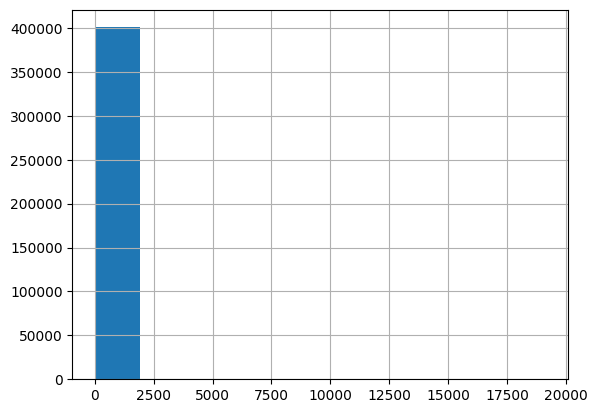

In [37]:
df['Quantity'].hist()

In [38]:
df[df['Quantity']>329]['Quantity'].count()

np.int64(1000)

In [39]:
df_clean=df[df['Quantity']<329]

In [40]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 399947 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      399947 non-null  object 
 1   StockCode    399947 non-null  object 
 2   Description  399947 non-null  object 
 3   Quantity     399947 non-null  int64  
 4   InvoiceDate  399947 non-null  object 
 5   Price        399947 non-null  float64
 6   Customer ID  399947 non-null  float64
 7   Country      399947 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.5+ MB


* *Price*

<Axes: >

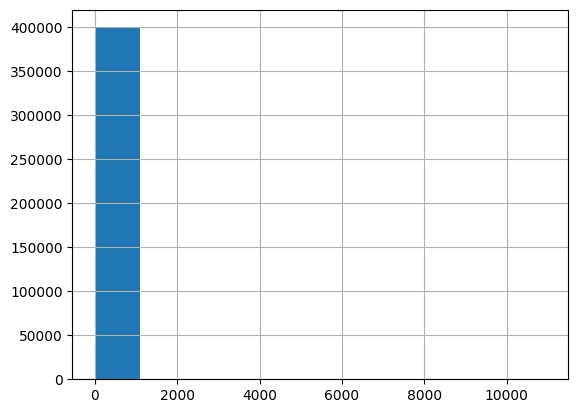

In [41]:
df_clean['Price'].hist()

In [42]:
# for just checking how many orders are there , We'll REMOVE those Orders while removing those Description 
df_clean[df_clean['Price']>900]['Price'].count()

np.int64(21)

In [43]:
df_clean[df_clean['Price']>900]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
22960,491176,M,Manual,1,12/10/2009 11:50:00,1213.02,13091.0,United Kingdom
51493,494042,M,Manual,1,01/11/2010 11:57:00,975.11,12510.0,Spain
65449,495235,M,Manual,1,01/22/2010 09:40:00,1193.89,14156.0,EIRE
74356,496115,M,Manual,1,01/29/2010 11:04:00,8985.60,17949.0,United Kingdom
91068,497952,M,Manual,1,02/15/2010 12:31:00,1508.65,12380.0,Belgium
129903,501766,M,Manual,1,03/19/2010 11:35:00,6958.17,15760.0,Norway
129987,501768,M,Manual,1,03/19/2010 11:45:00,6958.17,15760.0,Norway
135013,502263,M,Manual,1,03/23/2010 15:22:00,10953.50,12918.0,United Kingdom
233555,512002,M,Manual,1,06/11/2010 15:54:00,1000.63,14255.0,United Kingdom
288706,517483,M,Manual,1,07/29/2010 12:29:00,3610.50,12737.0,France


While analyzing outlier in *Price* Column:
* No product in 'Description' column
* *Description* column majorly contain is **Manual**

*Note*: while analyzing *'Description'* .must fix this price column

#### Categorical COls:

In [44]:
df_clean.select_dtypes(include='object').describe().T

,count,unique,top,freq
Invoice,399947,19055,500356,251
StockCode,399947,4013,85123A,3093
Description,399947,4439,WHITE HANGING HEART T-LIGHT HOLDER,3093
InvoiceDate,399947,17870,03/07/2010 15:34:00,251
Country,399947,37,United Kingdom,363481


In [45]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/01/2009 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/01/2009 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/01/2009 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/01/2009 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/01/2009 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,12/09/2010 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,12/09/2010 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,12/09/2010 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,12/09/2010 20:01:00,3.75,17530.0,United Kingdom


##### Description:
* Postage: This is the shipping or delivery fee charged to the customer.
* Manual: This represents manual adjustments made to the invoice by store admins (e.g., service fees, corrections, manual credits, or custom adjustments).

Why You should remove them?
* Distorts the Monetary (M) Score
* Corrupts the Frequency (F) Score

In [46]:
df_clean['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     3093
REGENCY CAKESTAND 3 TIER               1695
STRAWBERRY CERAMIC TRINKET BOX         1372
ASSORTED COLOUR BIRD ORNAMENT          1346
HOME BUILDING BLOCK WORD               1192
                                       ... 
GOLD CHRISTMAS STOCKING DECORATION        1
WHITE ROSEBUD & PEARL NECKLACE            1
WRAP CHRISTMAS DECOUPAGE                  1
SILVER/NAT SHELL NECKLACE W PENDANT       1
BAKING MOULD EASTER EGG MILK CHOC         1
Name: count, Length: 4439, dtype: int64

In [47]:
df_clean[df_clean['Description']=='Manual']['Description'].value_counts()

Description
Manual    421
Name: count, dtype: int64

In [48]:
df_clean[df_clean['Price']>300]['Description'].value_counts()

Description
Manual                                 50
POSTAGE                                 3
Adjustment by Peter on Jun 25 2010      2
Adjustment by john on 26/01/2010 16     1
Adjustment by john on 26/01/2010 17     1
Name: count, dtype: int64

In [49]:
df_clean['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER     3093
REGENCY CAKESTAND 3 TIER               1695
STRAWBERRY CERAMIC TRINKET BOX         1372
ASSORTED COLOUR BIRD ORNAMENT          1346
HOME BUILDING BLOCK WORD               1192
                                       ... 
GOLD CHRISTMAS STOCKING DECORATION        1
WHITE ROSEBUD & PEARL NECKLACE            1
WRAP CHRISTMAS DECOUPAGE                  1
SILVER/NAT SHELL NECKLACE W PENDANT       1
BAKING MOULD EASTER EGG MILK CHOC         1
Name: count, Length: 4439, dtype: int64

In [50]:
df_clean['Description'].astype(str)

df_clean=df_clean[~df_clean['Description'].isin(['Manual','Postage','POSTAGE','CARRIAGE','Bank Charges','Bank Charges','This is a test product.','Discount'])]

In [51]:
df_clean[df_clean['Price']>300]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
71038,495755,ADJUST,Adjustment by john on 26/01/2010 16,1,01/26/2010 16:29:00,342.80,14413.0,United Kingdom
71082,495802,ADJUST,Adjustment by john on 26/01/2010 17,1,01/26/2010 17:28:00,387.54,12748.0,United Kingdom
249672,513564,ADJUST2,Adjustment by Peter on Jun 25 2010,1,06/25/2010 14:15:00,300.13,17050.0,United Kingdom
249673,513566,ADJUST2,Adjustment by Peter on Jun 25 2010,1,06/25/2010 14:15:00,358.47,17364.0,United Kingdom


In [52]:
df_clean['Description'].str.contains('Adjustment').sum()

np.int64(35)

In [53]:
df_clean['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER    3093
REGENCY CAKESTAND 3 TIER              1695
STRAWBERRY CERAMIC TRINKET BOX        1372
ASSORTED COLOUR BIRD ORNAMENT         1346
HOME BUILDING BLOCK WORD              1192
                                      ... 
WHITE VINTAGE CRYSTAL EARRINGS           1
TURQ STONE/CRYSTAL EARRINGS              1
PARTY PIZZA DISH GREEN+WHITE SPOT        1
DADDY MOUSE RED GINGHAM BOW TIE          1
BAKING MOULD EASTER EGG MILK CHOC        1
Name: count, Length: 4433, dtype: int64

#### StockCode

In [54]:
df_clean[~df_clean['StockCode'].astype(str).str.match(r'^\d',na=False)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
18466,490948,BANK CHARGES,Bank Charges,1,12/08/2009 14:29:00,15.000,16805.0,United Kingdom
62299,494914,PADS,PADS TO MATCH ALL CUSHIONS,1,01/19/2010 17:04:00,0.001,16705.0,United Kingdom
70976,495733,ADJUST,Adjustment by john on 26/01/2010 16,1,01/26/2010 16:21:00,68.340,14911.0,EIRE
70977,495735,ADJUST,Adjustment by john on 26/01/2010 16,1,01/26/2010 16:22:00,201.560,12745.0,EIRE
70978,495734,ADJUST,Adjustment by john on 26/01/2010 16,1,01/26/2010 16:22:00,205.820,14911.0,EIRE
70980,495736,ADJUST,Adjustment by john on 26/01/2010 16,1,01/26/2010 16:23:00,21.000,12606.0,Spain
70985,495742,ADJUST,Adjustment by john on 26/01/2010 16,1,01/26/2010 16:25:00,63.240,12404.0,Finland
71022,495745,ADJUST,Adjustment by john on 26/01/2010 16,1,01/26/2010 16:26:00,56.730,12466.0,France
71023,495748,ADJUST,Adjustment by john on 26/01/2010 16,1,01/26/2010 16:26:00,117.720,16291.0,Portugal
71033,495747,ADJUST,Adjustment by john on 26/01/2010 16,1,01/26/2010 16:26:00,129.230,12555.0,Spain


In [55]:
discardStockCode=['BANK CHARGES','PADS','ADJUST','ADJUST2','SP1002']

for discardK in discardStockCode:
    df_clean=df_clean[~df_clean['StockCode'].astype(str).str.contains(discardK)]

In [56]:
df_clean[df_clean['StockCode'].astype(str).str.contains('PADS')]


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [57]:
df_clean.shape

(398580, 8)

In [58]:
df_clean.select_dtypes(include='object').describe().T

,count,unique,top,freq
Invoice,398580,18805,500356,251
StockCode,398580,4002,85123A,3093
Description,398580,4427,WHITE HANGING HEART T-LIGHT HOLDER,3093
InvoiceDate,398580,17669,03/07/2010 15:34:00,251
Country,398580,37,United Kingdom,363009


In [59]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398580 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      398580 non-null  object 
 1   StockCode    398580 non-null  object 
 2   Description  398580 non-null  object 
 3   Quantity     398580 non-null  int64  
 4   InvoiceDate  398580 non-null  object 
 5   Price        398580 non-null  float64
 6   Customer ID  398580 non-null  float64
 7   Country      398580 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.4+ MB


#### Country : 
column is already cleaned

In [60]:
df_clean['Country'].value_counts()

Country
United Kingdom          363009
EIRE                      8328
Germany                   7370
France                    5232
Netherlands               2618
Spain                     1181
Switzerland               1146
Belgium                    988
Portugal                   955
Sweden                     820
Channel Islands            817
Italy                      693
Australia                  623
Cyprus                     531
Greece                     511
Austria                    504
Norway                     362
Denmark                    354
Finland                    338
United Arab Emirates       313
Unspecified                277
USA                        225
Poland                     181
Malta                      168
Japan                      162
Lithuania                  154
Singapore                  117
Canada                      77
Thailand                    76
Israel                      74
Iceland                     71
RSA                         65


In [61]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='mixed', errors='coerce')

In [62]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [63]:
df_clean.isna().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [64]:
df_clean[df_clean["Invoice"].str.match("^\\d{6}$") == False]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [65]:
df_clean["Invoice"].str.replace("[0-9]", "", regex=True).unique()

array([''], dtype=object)

In [66]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [67]:
df_clean.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,398580.000000,398580,398580.000000,398580.000000
mean,11.220480,2010-07-01 05:48:09.630889472,3.003052,15366.025217
min,1.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-03-26 13:45:00,1.250000,13995.000000
50%,5.000000,2010-07-09 11:43:00,1.950000,15311.000000
75%,12.000000,2010-10-14 14:11:00,3.750000,16807.000000
max,327.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,23.243367,NaN,4.313820,1677.646704


In [68]:
df_clean=df_clean[df_clean['Price']>0.0]
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398553 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      398553 non-null  object        
 1   StockCode    398553 non-null  object        
 2   Description  398553 non-null  object        
 3   Quantity     398553 non-null  int64         
 4   InvoiceDate  398553 non-null  datetime64[ns]
 5   Price        398553 non-null  float64       
 6   Customer ID  398553 non-null  float64       
 7   Country      398553 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.4+ MB


In [69]:
df_clean.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,398553.000000,398553,398553.000000,398553.000000
mean,11.220711,2010-07-01 05:51:50.905751552,3.003256,15366.120925
min,1.000000,2009-12-01 07:45:00,0.040000,12346.000000
25%,2.000000,2010-03-26 13:45:00,1.250000,13996.000000
50%,5.000000,2010-07-09 11:43:00,1.950000,15311.000000
75%,12.000000,2010-10-14 14:11:00,3.750000,16807.000000
max,327.000000,2010-12-09 20:01:00,295.000000,18287.000000
std,23.243918,NaN,4.313895,1677.611138


In [70]:
df_clean[df_clean['Price']<0.1]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
6358,489880,72038P,PRICE'S CANDLE PEACH,200,2009-12-02 16:18:00,0.08,13313.0,United Kingdom
6361,489880,35015,JACOBS LADDER SMALL,72,2009-12-02 16:18:00,0.06,13313.0,United Kingdom
6425,489888,35015,JACOBS LADDER SMALL,72,2009-12-02 16:49:00,0.06,14841.0,United Kingdom
6560,489900,17136A,BLUE STONES ON WIRE FOR CANDLE,24,2009-12-03 09:44:00,0.08,14771.0,United Kingdom
10731,490279,35015,JACOBS LADDER SMALL,1,2009-12-04 12:37:00,0.06,16891.0,United Kingdom
...,...,...,...,...,...,...,...,...
439033,531353,35015,JACOBS LADDER SMALL,15,2010-11-07 13:47:00,0.06,15571.0,United Kingdom
447057,531945,17136A,BLUE STONES ON WIRE FOR CANDLE,48,2010-11-10 12:16:00,0.08,12997.0,United Kingdom
450459,532153,17136A,BLUE STONES ON WIRE FOR CANDLE,24,2010-11-11 12:14:00,0.08,16945.0,United Kingdom
481282,534471,17136A,BLUE STONES ON WIRE FOR CANDLE,24,2010-11-23 10:24:00,0.08,17422.0,United Kingdom


In [71]:
len(df)

400947

In [72]:
len(df_clean)

398553

In [73]:
df_clean[df_clean['StockCode']=='PADS']

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [74]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398553 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      398553 non-null  object        
 1   StockCode    398553 non-null  object        
 2   Description  398553 non-null  object        
 3   Quantity     398553 non-null  int64         
 4   InvoiceDate  398553 non-null  datetime64[ns]
 5   Price        398553 non-null  float64       
 6   Customer ID  398553 non-null  float64       
 7   Country      398553 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.4+ MB


In [75]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [76]:
df_clean[df_clean['Price']==0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [77]:
df_clean.duplicated().sum()

np.int64(0)

### Feature Engineering
* Total sum:creating new column  by multiplying *'Quantity * Price'*

In [78]:
df_clean['TotalSum']=df_clean['Price']*df_clean['Quantity']

In [79]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


* InvoiceDate: To calculate Recency, your date column must be a proper datetime object so Python can subtract days accurately.

In [80]:
df_clean['InvoiceDate']=pd.to_datetime(df_clean['InvoiceDate'])

In [81]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398553 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      398553 non-null  object        
 1   StockCode    398553 non-null  object        
 2   Description  398553 non-null  object        
 3   Quantity     398553 non-null  int64         
 4   InvoiceDate  398553 non-null  datetime64[ns]
 5   Price        398553 non-null  float64       
 6   Customer ID  398553 non-null  float64       
 7   Country      398553 non-null  object        
 8   TotalSum     398553 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


*INSIGHT:* SO far we have cleaned our data ,now heading toward EDA

removing 'Unspecified' Country name

In [82]:
df_clean=df_clean[df_clean['Country']!='Unspecified']

## EDA

* What is the Data Date Range?

In [83]:
print(f"Last Date : {df_clean['InvoiceDate'].max()} \nStarting Date: {df_clean['InvoiceDate'].min()}")

Last Date : 2010-12-09 20:01:00 
Starting Date: 2009-12-01 07:45:00


In [84]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [85]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,398276.0,11.220159,1.0,2.0,5.0,12.0,327.0,23.249937
InvoiceDate,398276,2010-07-01 05:50:14.114031616,2009-12-01 07:45:00,2010-03-26 13:45:00,2010-07-09 10:26:00,2010-10-14 14:18:00,2010-12-09 20:01:00,NaN
Price,398276.0,3.003079,0.04,1.25,1.95,3.75,295.0,4.314617
Customer ID,398276.0,15366.13678,12346.0,13995.0,15311.0,16809.0,18287.0,1677.737776
TotalSum,398276.0,20.131503,0.06,5.0,11.9,19.5,3884.0,46.470948


* Number of Unique Customer ID

In [86]:
df_clean['Customer ID'].nunique()

4267

In [87]:
df_clean.select_dtypes(include='number').agg(['min','max','mean'])

,Quantity,Price,Customer ID,TotalSum
min,1.000000,0.040000,12346.00000,0.060000
max,327.000000,295.000000,18287.00000,3884.000000
mean,11.220159,3.003079,15366.13678,20.131503


In [88]:
df_clean.select_dtypes(include='object')


,Invoice,StockCode,Description,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,United Kingdom
...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,United Kingdom


In [89]:
df_clean.nunique()

Invoice        18797
StockCode       4002
Description     4427
Quantity         177
InvoiceDate    17661
Price            285
Customer ID     4267
Country           36
TotalSum        2136
dtype: int64

* Most buying Product ?

In [90]:
df_clean['Description'].value_counts().head()

Description
WHITE HANGING HEART T-LIGHT HOLDER    3092
REGENCY CAKESTAND 3 TIER              1692
STRAWBERRY CERAMIC TRINKET BOX        1369
ASSORTED COLOUR BIRD ORNAMENT         1346
HOME BUILDING BLOCK WORD              1192
Name: count, dtype: int64

* Most buying country?

In [91]:
df_clean['Country'].value_counts().head()

Country
United Kingdom    362991
EIRE                8328
Germany             7363
France              5232
Netherlands         2617
Name: count, dtype: int64

* Top most product is most buying?

In [92]:
df_clean.groupby('Description').agg({'Quantity':'sum'}).sort_values('Quantity',ascending=False).head()

,Quantity
Description,
WHITE HANGING HEART T-LIGHT HOLDER,49359
PACK OF 72 RETRO SPOT CAKE CASES,37185
ASSORTED COLOUR BIRD ORNAMENT,35751
60 TEATIME FAIRY CAKE CASES,30976
WORLD WAR 2 GLIDERS ASSTD DESIGNS,30946


* TOp highly expensive buying product

In [93]:
df_clean[['Description','Price']].value_counts().sort_index(level='Price',ascending=False).head().reset_index(name='Count')

,Description,Price,Count
0,VINTAGE RED KITCHEN CABINET,295.0,15
1,VINTAGE BLUE KITCHEN CABINET,295.0,17
2,RUSTIC SEVENTEEN DRAWER SIDEBOARD,165.0,4
3,REGENCY MIRROR WITH SHUTTERS,165.0,2
4,GIANT SEVENTEEN DRAWER SIDEBOARD,165.0,4


* Which country gained how much price?

In [94]:
import matplotlib.pyplot as plt
CountryEarning=df_clean.groupby('Country').agg(TotalEarning=('TotalSum','sum'),
                                MinEarning=('TotalSum','min'),
                                MaxEarning=('TotalSum','max')
                                ).reset_index().sort_values(by='TotalEarning',ascending=False)
CountryEarning.head()

,Country,TotalEarning,MinEarning,MaxEarning
34,United Kingdom,6814020.44,0.06,3884.0
9,EIRE,312982.30,1.65,1990.0
21,Netherlands,242679.11,0.42,1544.4
12,Germany,181873.53,0.42,700.8
11,France,119614.56,0.42,734.4


Text(0, 0.5, 'Earning USD')

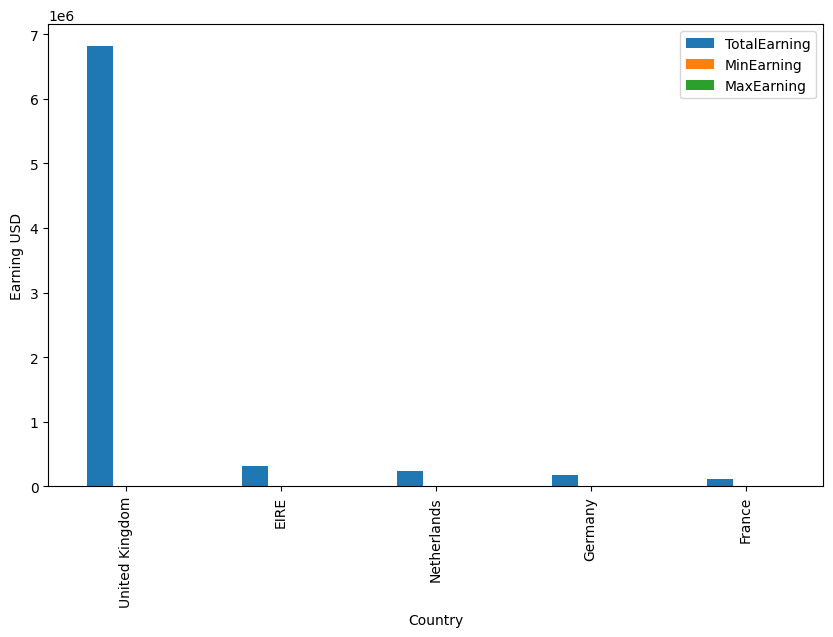

In [95]:
CountryEarning=CountryEarning.head()
CountryEarning.set_index('Country').plot(kind='bar',figsize=(10,6))
plt.ylabel('Earning USD')


C:\Users\MANN\AppData\Local\Temp\ipykernel_8468\2414725461.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=CountryEarning,x='TotalEarning',y='Country',palette='viridis')


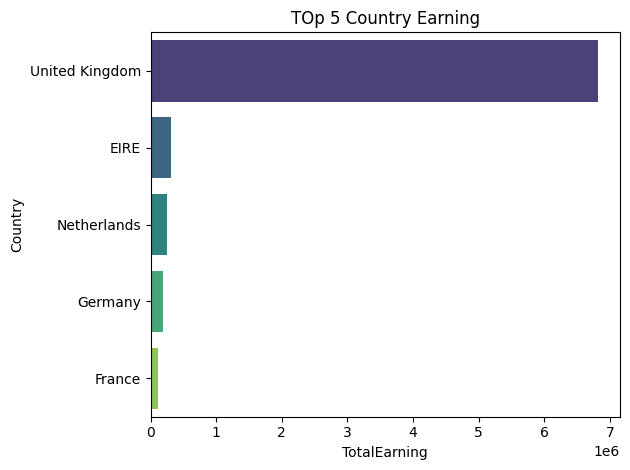

In [96]:
import seaborn as sns
sns.barplot(data=CountryEarning,x='TotalEarning',y='Country',palette='viridis')
plt.title("TOp 5 Country Earning")
plt.tight_layout()
plt.show()

* What is the average basket size? Calculate the average number of items and total spend per single Invoice.

In [97]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398276 entries, 0 to 525460
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      398276 non-null  object        
 1   StockCode    398276 non-null  object        
 2   Description  398276 non-null  object        
 3   Quantity     398276 non-null  int64         
 4   InvoiceDate  398276 non-null  datetime64[ns]
 5   Price        398276 non-null  float64       
 6   Customer ID  398276 non-null  float64       
 7   Country      398276 non-null  object        
 8   TotalSum     398276 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [98]:
bsktSize=df_clean.groupby('Invoice').agg(TotalProduct=('Quantity','sum'),
                                TotalSum=('TotalSum','sum')
                                ).reset_index()
print(f'Average Item basket Quantity per size: {bsktSize['TotalProduct'].mean()}')
print(f'Average Item basket Price per size: {bsktSize['TotalSum'].mean()}')


Average Item basket Quantity per size: 237.73580890567644
Average Item basket Price per size: 426.55180986327605


* When do people shop the most? Extract features from Invoice Date to find peak shopping hours, days of the week, or seasonal trends (e.g., holiday spikes).

In [99]:
df_clean['InvoiceDate'].value_counts().sort_values(ascending=False).head(10)

InvoiceDate
2010-03-07 15:34:00    251
2010-05-07 09:04:00    250
2010-10-08 12:14:00    240
2010-06-08 16:47:00    240
2010-06-06 12:13:00    236
2010-11-07 16:29:00    228
2010-10-07 16:48:00    226
2010-11-28 14:57:00    215
2010-05-16 16:05:00    201
2010-11-21 13:13:00    200
Name: count, dtype: int64

In [100]:
df_clean['hours']=df_clean['InvoiceDate'].dt.hour
df_clean['weeks']=df_clean['InvoiceDate'].dt.day_of_week
df_clean['month']=df_clean['InvoiceDate'].dt.month

In [101]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum,hours,weeks,month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,1,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,1,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,1,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,1,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,1,12


#### Product Selling by time period(Visualization)
* Peak Month

In [102]:
peakMonth=df_clean.groupby('month')['Invoice'].nunique().reset_index(name='Orders')
peakMonth = peakMonth.sort_values('month')

months_order = ['January', 'February', 'March', 'April', 'May', 'June', 
                'July', 'August', 'September', 'October', 'November', 'December']
# peakMonth['month'] = pd.Categorical(peakMonth['month'], categories=months_order, ordered=True)
peakMonth['month']=months_order
peakMonth

,month,Orders
0,January,950
1,February,1086
2,March,1494
3,April,1308
4,May,1355
5,June,1464
6,July,1352
7,August,1265
8,September,1638
9,October,2089


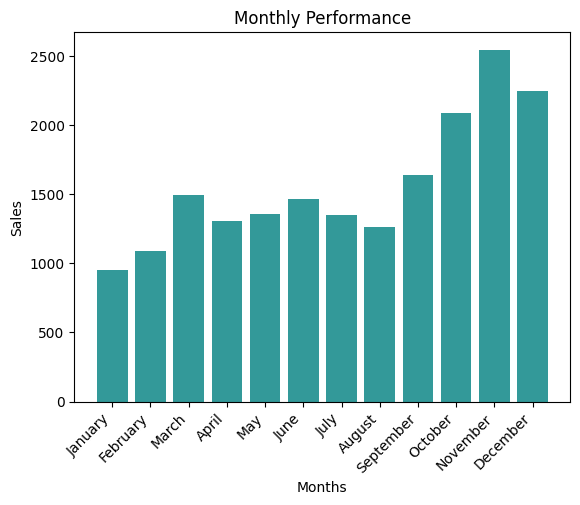

In [103]:
plt.bar(peakMonth['month'],peakMonth['Orders'],color='teal',alpha=0.8)
plt.title("Monthly Performance")
plt.xlabel("Months")
plt.ylabel('Sales')
plt.xticks(rotation=45,ha='right')
plt.show()

*Insights:*
* Top Monthly sale is in *November*,end of the Month
* Most selling Months (October,November,December)
* Starting of the Year lowest sale

* Peak Hour:

In [104]:
peakWOD=df_clean.groupby('weeks')['Invoice'].nunique().reset_index(name='sale')
peakWOD=peakWOD.sort_values('weeks')
daysOrder=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
peakWOD['weeks']=daysOrder
peakWOD

,weeks,sale
0,Monday,2914
1,Tuesday,3410
2,Wednesday,3358
3,Thursday,3894
4,Friday,2537
5,Saturday,30
6,Sunday,2654


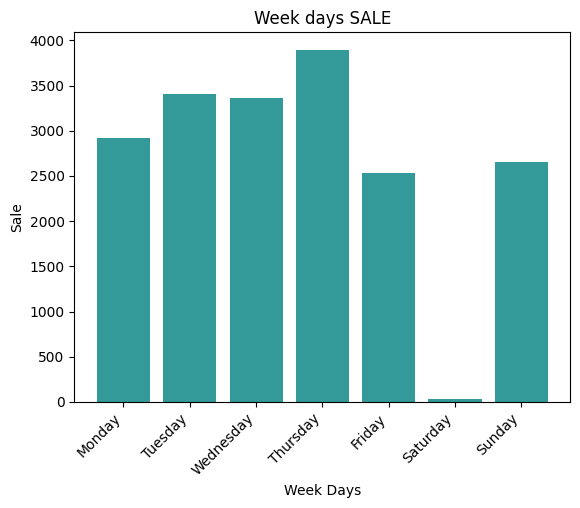

In [105]:
plt.bar(peakWOD['weeks'],peakWOD['sale'],color='teal',alpha=0.8)
plt.title('Week days SALE')
plt.xlabel('Week Days')
plt.ylabel('Sale')
plt.xticks(rotation=45,ha='right')
plt.show()

Insight:
* Thursday is Most Peak day
* Sunday to THursday sale increase
* Friday to Saturday Sale drops

* *Hourly Sale:*

In [106]:
peakHours=df_clean.groupby('hours')['Invoice'].nunique().reset_index(name='sale')
peakHours.sort_values('hours')

,hours,sale
0,7,49
1,8,441
2,9,1173
3,10,2178
4,11,2358
5,12,3110
6,13,2848
7,14,2318
8,15,2020
9,16,1212


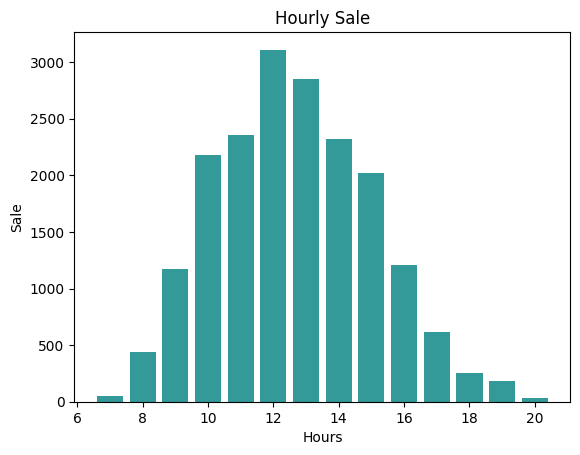

In [107]:
plt.bar(peakHours['hours'],peakHours['sale'],color='teal',alpha=0.8)
plt.title("Hourly Sale")
plt.xlabel('Hours')
plt.ylabel('Sale')
plt.show()

Insight:
* Normally Distributed visualization
* 10 to 14 purely *peak hour*(Mid of the day)
* Starting of the day sales are Low it will slowly increase
* End of the day Sale reduces

In [108]:
print(f'Average Sale Price of the year {df_clean['TotalSum'].sum()/len(df_clean)}')

Average Sale Price of the year 20.131502701644084


### Revenue Earningby time period (Visualization)
* Monthly

In [109]:
RevenueMonth=df_clean.groupby('month')['TotalSum'].sum().reset_index(name='Monthly Earning')
RevenueMonth['month']=months_order
RevenueMonth

,month,Monthly Earning
0,January,493357.48
1,February,463679.33
2,March,614147.60
3,April,561734.09
4,May,556256.31
5,June,579000.78
6,July,561611.00
7,August,561046.08
8,September,718239.10
9,October,942725.71


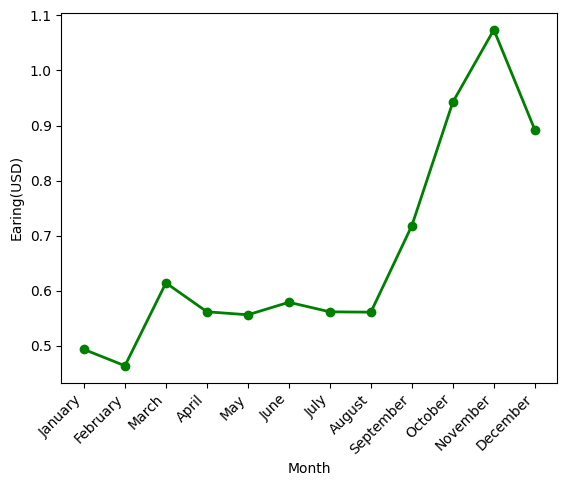

In [110]:
plt.plot(RevenueMonth['month'],RevenueMonth['Monthly Earning']/1000000,marker='o',color='green',linewidth=2)
plt.xlabel('Month')
plt.ylabel('Earing(USD)')
plt.xticks(rotation=45,ha='right')
# plt.ticklabel_format(style='sci',axis='y')
plt.show()

* Weekly Sale

In [111]:
RevenueWeek=df_clean.groupby('weeks')['TotalSum'].sum().reset_index(name='Monthly Earning')
RevenueWeek['weeks']=daysOrder
RevenueWeek

,weeks,Monthly Earning
0,Monday,1251331.22
1,Tuesday,1529111.20
2,Wednesday,1431542.30
3,Thursday,1682604.43
4,Friday,1114758.68
5,Saturday,9803.05
6,Sunday,998743.49


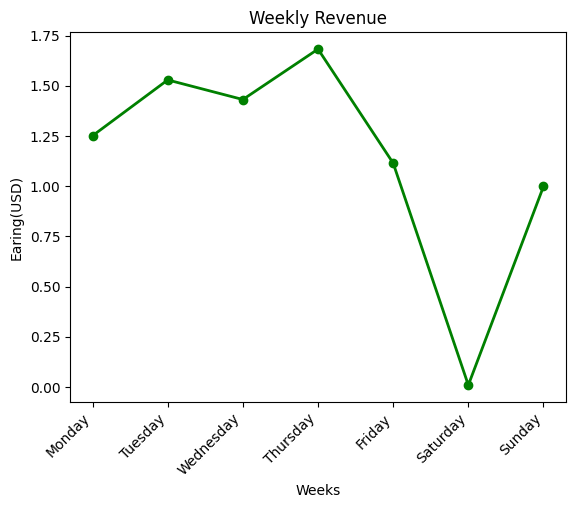

In [112]:
plt.plot(RevenueWeek['weeks'],RevenueWeek['Monthly Earning']/1000000,marker='o',color='green',linewidth=2)
plt.xlabel('Weeks')
plt.ylabel('Earing(USD)')
plt.xticks(rotation=45,ha='right')
plt.title("Weekly Revenue")
plt.show()

* Timely(hours) Revenue

In [113]:
RevenueHours=df_clean.groupby('hours')['TotalSum'].sum().reset_index(name='Revenue(USD)')
RevenueHours

,hours,Revenue(USD)
0,7,42366.56
1,8,237230.93
2,9,588818.98
3,10,1000570.48
4,11,988362.00
5,12,1259286.56
6,13,1139502.66
7,14,958340.60
8,15,848265.85
9,16,530983.56


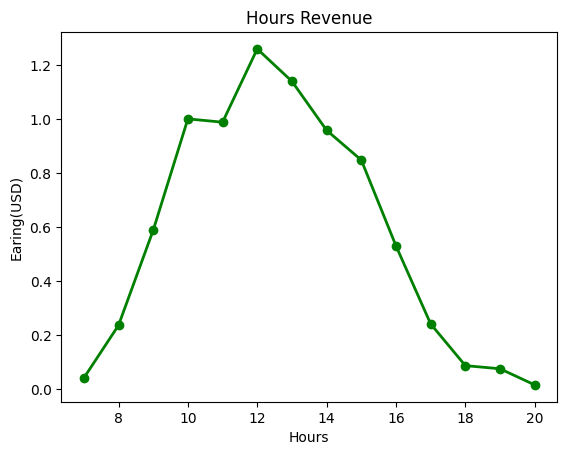

In [114]:
plt.plot(RevenueHours['hours'],RevenueHours['Revenue(USD)']/1000000 , marker='o' , color='green' , linewidth=2)
plt.xlabel('Hours')
plt.ylabel('Earing(USD)')
plt.title("Hours Revenue")
plt.show()

In [115]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum,hours,weeks,month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,1,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,1,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,1,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,1,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,1,12


In [116]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398276 entries, 0 to 525460
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      398276 non-null  object        
 1   StockCode    398276 non-null  object        
 2   Description  398276 non-null  object        
 3   Quantity     398276 non-null  int64         
 4   InvoiceDate  398276 non-null  datetime64[ns]
 5   Price        398276 non-null  float64       
 6   Customer ID  398276 non-null  float64       
 7   Country      398276 non-null  object        
 8   TotalSum     398276 non-null  float64       
 9   hours        398276 non-null  int32         
 10  weeks        398276 non-null  int32         
 11  month        398276 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(3), int64(1), object(4)
memory usage: 34.9+ MB


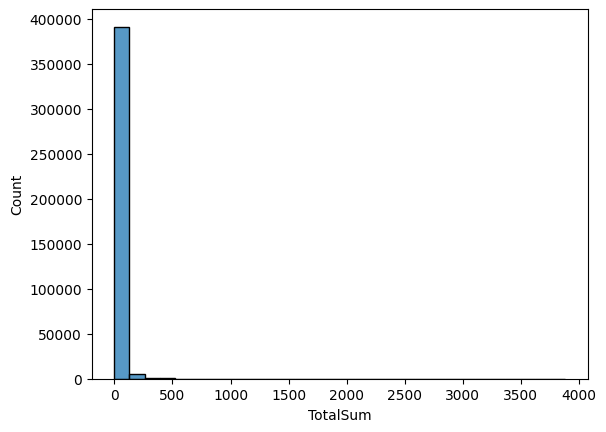

<Figure size 1000x600 with 0 Axes>

In [117]:
sns.histplot(df_clean['TotalSum'],bins=30)
plt.figure(figsize=(10,6))
plt
plt.show()

## Feature Engineering

Aggregated Data based on Customer ID(RFM)

In [118]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum,hours,weeks,month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,1,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,1,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,1,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,1,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,1,12


In [119]:
# Creating new Data based(RFM) on Customer ID 
aggregated_df=df_clean.groupby('Customer ID').agg(MonetaryValue=('TotalSum','sum'),
                                                  Frequency=('Invoice','nunique'),
                                                  LastInvoiceDate=('InvoiceDate','max')
                                                  ).reset_index()
aggregated_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.0,169.36,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12352.0,343.80,2,2010-11-29 10:07:00


In [120]:
aggregated_df[aggregated_df['Customer ID']==12346.0]

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.0,169.36,2,2010-06-28 13:53:00


Recency Finding out

In [121]:
# Maximum date finding
max_invoice_date=aggregated_df['LastInvoiceDate'].max()
max_invoice_date

Timestamp('2010-12-09 20:01:00')

In [122]:
aggregated_df['Recency']=(max_invoice_date-aggregated_df['LastInvoiceDate']).dt.days
aggregated_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12352.0,343.80,2,2010-11-29 10:07:00,10


#### Visualizing of RFM
* Histogram

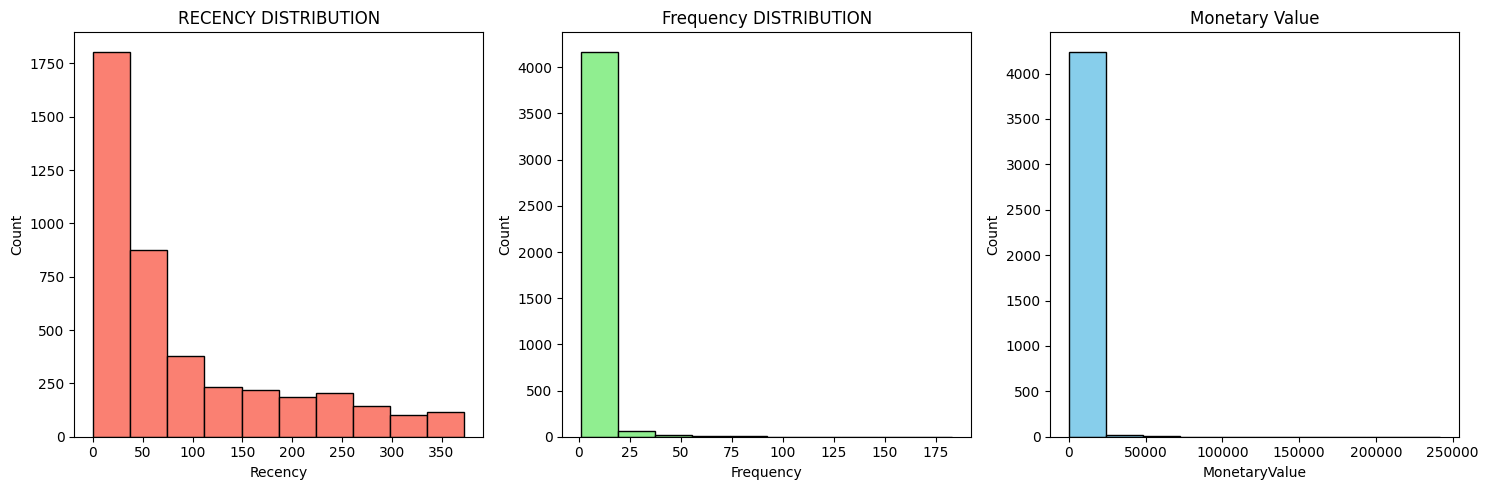

In [123]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.hist(aggregated_df['Recency'],bins=10,color='salmon',edgecolor='black')
plt.xlabel('Recency')
plt.ylabel('Count')
plt.title("RECENCY DISTRIBUTION")

plt.subplot(1,3,2)
plt.hist(aggregated_df['Frequency'],bins=10,color='lightgreen',edgecolor='black')
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.title("Frequency DISTRIBUTION")

plt.subplot(1,3,3)
plt.hist(aggregated_df['MonetaryValue'],bins=10,color='skyblue',edgecolor='black')
plt.xlabel('MonetaryValue')
plt.ylabel('Count')
plt.title("Monetary Value")

plt.tight_layout()
plt.show()

These graphs show that your RFM data is **highly right-skewed with extreme outliers**, which is normal for retail data.Most customers buy infrequently and spend small amounts, while a tiny group generates massive value.

* **Recency (Red):** Right-skewed distribution. Many customers bought recently (under 50 days). A steady decline follows.
* **Frequency (Green):** Extreme right skew. Almost all customers made under 25 purchases. A few outliers bought up to 175 times.
* **Monetary Value (Blue):** Severe extreme skew. Most customers spent under $25,000. Rare whales spent up to $250,000.

* BoxPlot

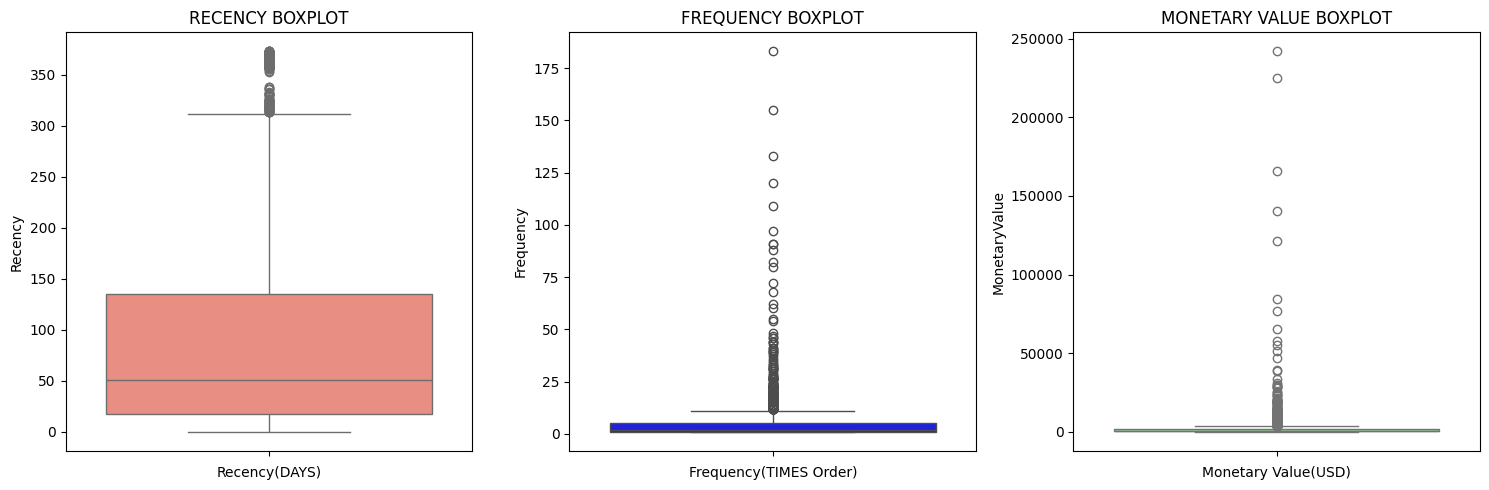

In [124]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(aggregated_df['Recency'] ,color='salmon')
plt.xlabel('Recency(DAYS)')
plt.title('RECENCY BOXPLOT')

plt.subplot(1,3,2)
sns.boxplot(aggregated_df['Frequency'] , color='blue')
plt.xlabel('Frequency(TIMES Order)')
plt.title('FREQUENCY BOXPLOT')

plt.subplot(1,3,3)
sns.boxplot(aggregated_df['MonetaryValue'] , color='lightgreen')
plt.xlabel('Monetary Value(USD)')
plt.title('MONETARY VALUE BOXPLOT')

plt.tight_layout()
plt.show()

**📦 Quick Refresher:** How to Read the Box
* **The Box:** Represents the middle 50% of your customers (Interquartile Range / IQR).
* **The Center Line:** The median (the middle customer).
* **The Dots:** Individual outlier customers who sit far outside normal behavior.

**📊 Breakdown of Your Data1.**

**1. Recency Boxplot (Red)**

**What it shows:** The most distributed and "normal" metric of the three.
* **The Median:** Sits around **50 days**, meaning half your customers bought within the last 50 days.
* **The Box**: Most customers fall between ~15 and ~135 days since their last purchase.
* **Outliers:** A few dots above 310 days. These are old, dormant customers who haven't engaged in nearly a year.

**2. Frequency Boxplot (Blue)**

What it shows: Heavy data compression.
* **The Box:** The box is completely flattened at the bottom. This means the vast majority of customers only ordered **1 to 5 times**.
* **Outliers:** A massive, dense vertical line of dots shooting all the way up to **180 orders**. These are your highly systematic, recurring wholesale buyers or B2B clients.

**3. Monetary Value Boxplot (Gray)**

**What it shows:** The most extreme distribution in your dataset.
* **The Box:** Completely flattened against the $0 baseline. The average retail spend is tiny compared to the scale of the chart.
* **Outliers:** A long string of "whale" accounts spending between **$25,000 and $250,000**.

### IQR for RFM
Removing Outliers from **aggregated_df**
* Monetary value IQR

In [125]:
M_Q1=aggregated_df['MonetaryValue'].quantile(0.25)
M_Q3=aggregated_df['MonetaryValue'].quantile(0.75)
M_IQR=M_Q3 - M_Q1

monetary_outliers_df=aggregated_df[(aggregated_df['MonetaryValue']>(M_Q3+1.5*M_IQR)) | (aggregated_df['MonetaryValue']<(M_Q1-1.5*M_IQR))].copy()
monetary_outliers_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
8,12357.0,11229.99,1,2010-11-16 10:05:00,23
24,12380.0,4782.84,4,2010-08-31 14:54:00,100
41,12409.0,12346.62,4,2010-10-15 10:24:00,55
47,12415.0,19131.24,4,2010-11-29 15:07:00,10
60,12431.0,4145.52,11,2010-12-01 10:03:00,8
...,...,...,...,...,...
4219,18226.0,6324.43,15,2010-11-26 15:51:00,13
4223,18231.0,4776.50,23,2010-10-29 14:17:00,41
4232,18245.0,3757.92,13,2010-11-25 16:52:00,14
4235,18251.0,9712.64,6,2010-08-20 12:28:00,111


In [126]:
monetary_upper_fence=M_Q3+(1.5*M_IQR)
monetary_upper_fence

np.float64(3734.540000000001)

In [127]:
monetary_outliers_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,418.000000,418.000000,418.000000,418,418.000000
mean,15099.700957,10936.904426,17.081340,2010-11-11 02:00:16.076554752,28.468900
min,12357.000000,3737.380000,1.000000,2009-12-10 18:03:00,0.000000
25%,13603.000000,4504.455000,8.000000,2010-11-09 10:10:00,3.000000
50%,14956.500000,6002.355000,12.000000,2010-11-26 15:03:30,13.000000
75%,16696.000000,9502.580000,18.000000,2010-12-06 11:21:00,30.000000
max,18260.000000,241958.050000,183.000000,2010-12-09 19:32:00,364.000000
std,1728.062357,21276.617299,19.417861,NaN,49.250987


* Frequency

In [128]:
F_Q1=aggregated_df['Frequency'].quantile(0.25)
F_Q3=aggregated_df['Frequency'].quantile(0.75)
F_IQR=F_Q3-F_Q1

frequency_outliers=aggregated_df[(aggregated_df['Frequency']>(F_Q3+1.5*F_IQR)) | (aggregated_df['Frequency']<(F_Q1-1.5*F_IQR))].copy()
frequency_outliers.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,274.000000,274.000000,274.000000,274,274.000000
mean,15350.565693,13094.326679,23.675182,2010-11-23 05:25:39.416058112,16.324818
min,12437.000000,1091.440000,12.000000,2010-05-12 16:51:00,0.000000
25%,13809.250000,4296.230000,13.000000,2010-11-21 10:52:15,2.000000
50%,15411.500000,6225.670000,17.000000,2010-12-02 10:42:30,7.000000
75%,16806.000000,11363.575000,23.000000,2010-12-07 12:03:45,18.000000
max,18260.000000,241958.050000,183.000000,2010-12-09 19:32:00,211.000000
std,1741.417175,26008.754213,21.663096,NaN,27.255412


In [129]:
frequency_upper_fence=F_Q3+(1.5*F_IQR)
frequency_upper_fence

np.float64(11.0)

In [130]:
print(f"Monetary Outlier Threshold: > {monetary_upper_fence:.2f}")
print(f"Frequency Outlier Threshold: > {frequency_upper_fence:.2f}")

Monetary Outlier Threshold: > 3734.54
Frequency Outlier Threshold: > 11.00


saving Upper IQR Fence value in artifacts

In [131]:
iqr_thresholds={
    'monetary_upper':monetary_upper_fence,
    'frequency_upper':frequency_upper_fence
}
import joblib
# 1. Define your specific folder location
output_dir = "./artifacts"
os.makedirs(output_dir, exist_ok=True)  # Creates folder if it does not exist

# 2. Build the full file path
file_path = os.path.join(output_dir, "iqr_thresholds.joblib")
# 3. Saving the Scaler
joblib.dump(iqr_thresholds,file_path)

['./artifacts\\iqr_thresholds.joblib']

In [132]:
non_outlier_df=aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index)) & (~aggregated_df.index.isin(frequency_outliers.index))]
non_outlier_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3798.000000,3798.000000,3798.000000,3798,3798.000000
mean,15379.026066,871.457991,2.865982,2010-09-03 08:30:40.821485056,97.197472
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00,0.000000
25%,13911.250000,274.950000,1.000000,2010-07-08 14:20:00,22.000000
50%,15391.500000,576.590000,2.000000,2010-10-12 14:28:00,58.000000
75%,16856.750000,1248.337500,4.000000,2010-11-17 13:13:30,154.000000
max,18287.000000,3721.450000,11.000000,2010-12-09 20:01:00,373.000000
std,1692.599346,804.033825,2.253303,NaN,98.113380


Visualize after IQR

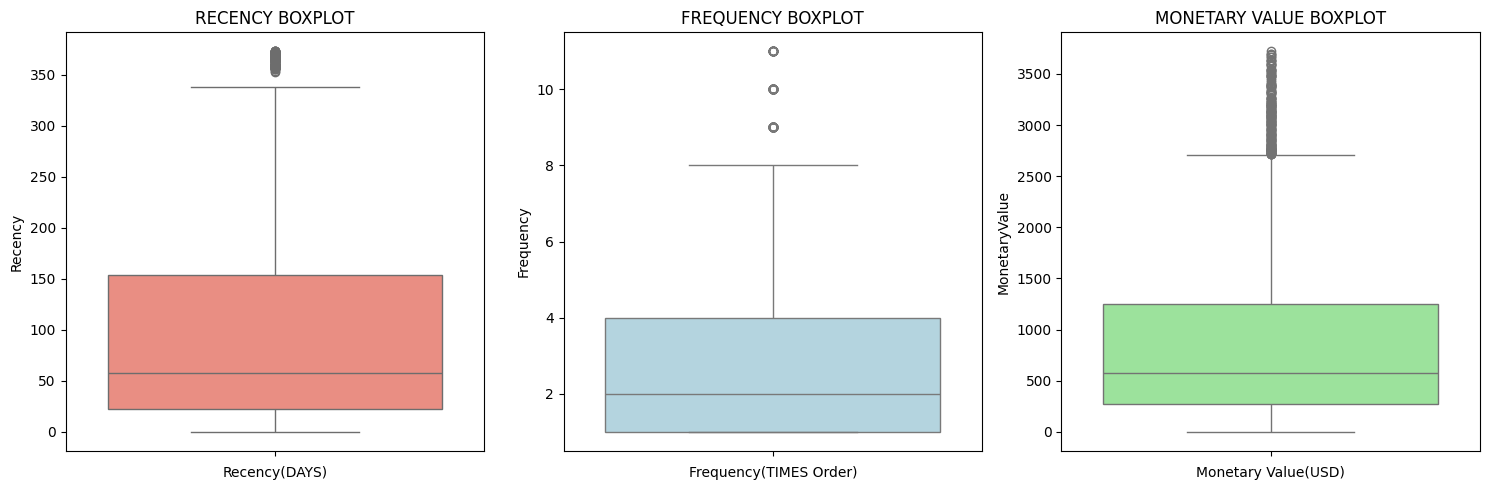

In [133]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(non_outlier_df['Recency'] ,color='salmon')
plt.xlabel('Recency(DAYS)')
plt.title('RECENCY BOXPLOT')

plt.subplot(1,3,2)
sns.boxplot(non_outlier_df['Frequency'] , color='lightblue')
plt.xlabel('Frequency(TIMES Order)')
plt.title('FREQUENCY BOXPLOT')

plt.subplot(1,3,3)
sns.boxplot(non_outlier_df['MonetaryValue'] , color='lightgreen')
plt.xlabel('Monetary Value(USD)')
plt.title('MONETARY VALUE BOXPLOT')

plt.tight_layout()
plt.show()

**📦 Quick Refresher:** How to Read the Box
* **The Box:** Represents the middle 50% of your customers (Interquartile Range / IQR).
* **The Center Line:** The median (the middle customer).
* **The Dots:** Individual outlier customers who sit far outside normal behavior.

**📊 Breakdown of Your Data1.**

__1. Recency Boxplot (Days)__
* **Median (Middle Line):** Sitting around 55 days. Half of your customers have purchased within the last 2 months.
* **Spread (IQR):** Most customers (the main box) fall between roughly 20 and 155 days since their last purchase.
* **Outliers (Top Dots):** There are several inactive customers who haven't bought anything in over 350 days.

__2. Frequency Boxplot (Order Count)__
* **Median:** Sitting exactly at 2 orders. Your typical customer is a repeat buyer but only does so twice.
* **Spread:** The bulk of your base (the box) has placed between 1 and 4 orders.
* **Outliers:** A tiny group of power users has placed 9 to 11+ orders.

__3. Monetary Value Boxplot (USD)__
*** Median:** Sitting around $550. Half your customers spend less than this, half spend more.
* **Spread:** Most customers spend between roughly $250 and $1,250.
* **Outliers:** There is a huge, dense column of high-value "whale" outliers stretching from $2,700 up to over $3,700.

In [134]:
non_outlier_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12352.0,343.80,2,2010-11-29 10:07:00,10


__3D Scatter Plor of RFM__

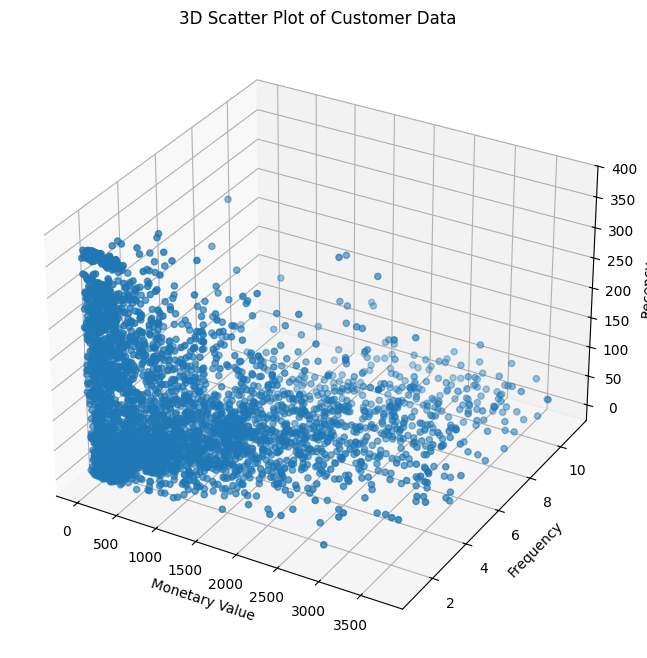

In [135]:
fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(projection="3d")
scatter=ax.scatter(non_outlier_df['MonetaryValue'],non_outlier_df['Frequency'],non_outlier_df['Recency'])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data')

plt.show()


__Breaking Down the Three Axes__

__X-Axis (Bottom Left): Monetary Value__
* What it measures: The total financial amount a customer has spent.
* Scale: Ranges from $0 to $4,000.
* Observation: The vast majority of your data points are tightly compressed below $500, showing a highly skewed distribution typical of e-commerce data.

__Y-Axis (Bottom Right):Frequency__
* What it measures: How many unique transactions or orders a customer has made.
* Scale: Ranges from 1 to roughly 11 purchases.
* Observation: Most dots cluster heavily along the lower end (1 to 4 purchases), indicating many one-time or low-frequency buyers.

__Z-Axis (Vertical Right): Recency__
* **What it measures:** The number of days elapsed since the customer's last purchase.
* **Scale:** Ranges from 0 days (recent) to 400 days (a long time ago).
* **Observation:** The dots form a vertical "wall" or tower extending all the way up from 0 to 400.

INsight:
* Data are on different Scales,K means algo are pretty sensitive ,Centroid will be shifted draatically


In [136]:
non_outlier_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12352.0,343.80,2,2010-11-29 10:07:00,10
...,...,...,...,...,...
4262,18283.0,619.37,6,2010-11-22 15:30:00,17
4263,18284.0,411.68,1,2010-10-04 11:33:00,66
4264,18285.0,377.00,1,2010-02-17 10:24:00,295
4265,18286.0,1246.43,2,2010-08-20 11:57:00,111


__Feature Transform__: Pretty helpful for finding right number of clusters & their labels
* **Log Transform:**(Monetary ,Frequency)

In [137]:
# log tranasform
import numpy as np

non_outlier_df['MonetaryValue_lg']=np.log1p(non_outlier_df['MonetaryValue'])
non_outlier_df['Frequency_lg']=np.log1p(non_outlier_df['Frequency'])
non_outlier_df

C:\Users\MANN\AppData\Local\Temp\ipykernel_8468\3311062355.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outlier_df['MonetaryValue_lg']=np.log1p(non_outlier_df['MonetaryValue'])
C:\Users\MANN\AppData\Local\Temp\ipykernel_8468\3311062355.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outlier_df['Frequency_lg']=np.log1p(non_outlier_df['Frequency'])


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,MonetaryValue_lg,Frequency_lg
0,12346.0,169.36,2,2010-06-28 13:53:00,164,5.137914,1.098612
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,7.188654,1.098612
2,12348.0,221.16,1,2010-09-27 14:59:00,73,5.403398,0.693147
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,7.706226,1.098612
4,12352.0,343.80,2,2010-11-29 10:07:00,10,5.842965,1.098612
...,...,...,...,...,...,...,...
4262,18283.0,619.37,6,2010-11-22 15:30:00,17,6.430316,1.945910
4263,18284.0,411.68,1,2010-10-04 11:33:00,66,6.022672,0.693147
4264,18285.0,377.00,1,2010-02-17 10:24:00,295,5.934894,0.693147
4265,18286.0,1246.43,2,2010-08-20 11:57:00,111,7.128841,1.098612


* __Standard Scaling:__
Standard scaling transforms the features of your data to have a mean of 0 and a standard deviation of 1, ensuring that each feature contributes equally to the analysis.

$$
z = \frac{x - \mu}{\sigma}
$$

Where:
- $z$ is the standardized value,
- $x$ is the original value,
- $\mu$ is the mean of the feature,
- $\sigma$ is the standard deviation of the feature.

* **Seperate Scaled DataFrame**

In [138]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
scaled_data=sc.fit_transform(non_outlier_df[['MonetaryValue_lg','Frequency_lg','Recency']])

scaled_data

array([[-1.1459472 , -0.2252474 ,  0.68096037],
       [ 0.8461307 , -0.2252474 , -0.97040798],
       [-0.88805753, -1.02453728, -0.24666012],
       ...,
       [-0.37176495, -1.02453728,  2.01632613],
       [ 0.78802802, -0.2252474 ,  0.14069788],
       [ 1.38095962,  0.78173876, -0.8175035 ]])

In [139]:
import joblib
# 1. Define your specific folder location
output_dir = "./artifacts"
os.makedirs(output_dir, exist_ok=True)  # Creates folder if it does not exist

# 2. Build the full file path
file_path = os.path.join(output_dir, "scaler.joblib")
# 3. Saving the Scaler
joblib.dump(sc,file_path)

['./artifacts\\scaler.joblib']

In [140]:
scaled_df=pd.DataFrame(data=scaled_data,index=non_outlier_df.index,columns=('MonetaryValue','Frequency','Recency'))

scaled_df

,MonetaryValue,Frequency,Recency
0,-1.145947,-0.225247,0.680960
1,0.846131,-0.225247,-0.970408
2,-0.888058,-1.024537,-0.246660
3,1.348897,-0.225247,-0.562663
4,-0.461065,-0.225247,-0.888859
...,...,...,...
4262,0.109485,1.445024,-0.817504
4263,-0.286498,-1.024537,-0.318016
4264,-0.371765,-1.024537,2.016326
4265,0.788028,-0.225247,0.140698


Standardised Scaled 3D plot

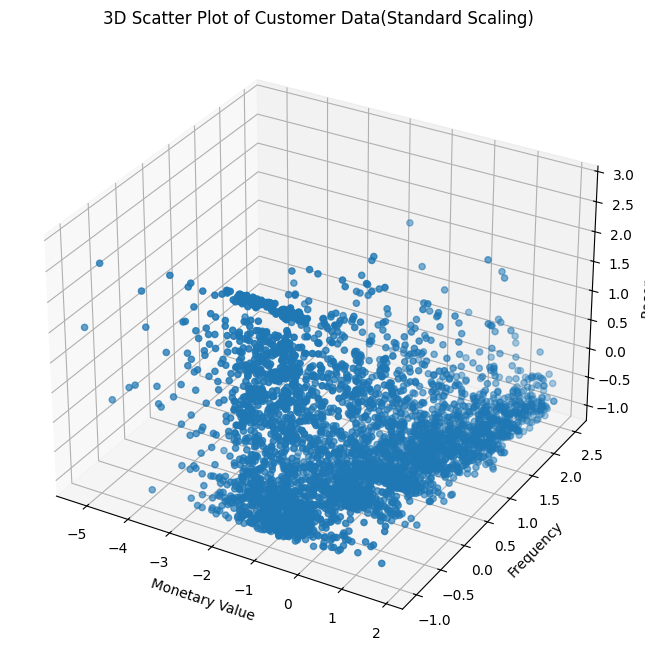

In [141]:
fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(projection='3d')
scatter=ax.scatter(scaled_df['MonetaryValue'],scaled_df['Frequency'],scaled_df['Recency'])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data(Standard Scaling)')

plt.show()

After scaling Data , Sacales have been changed , but shape of our data had n't ben changed yet

### __KMeans Clustering:__


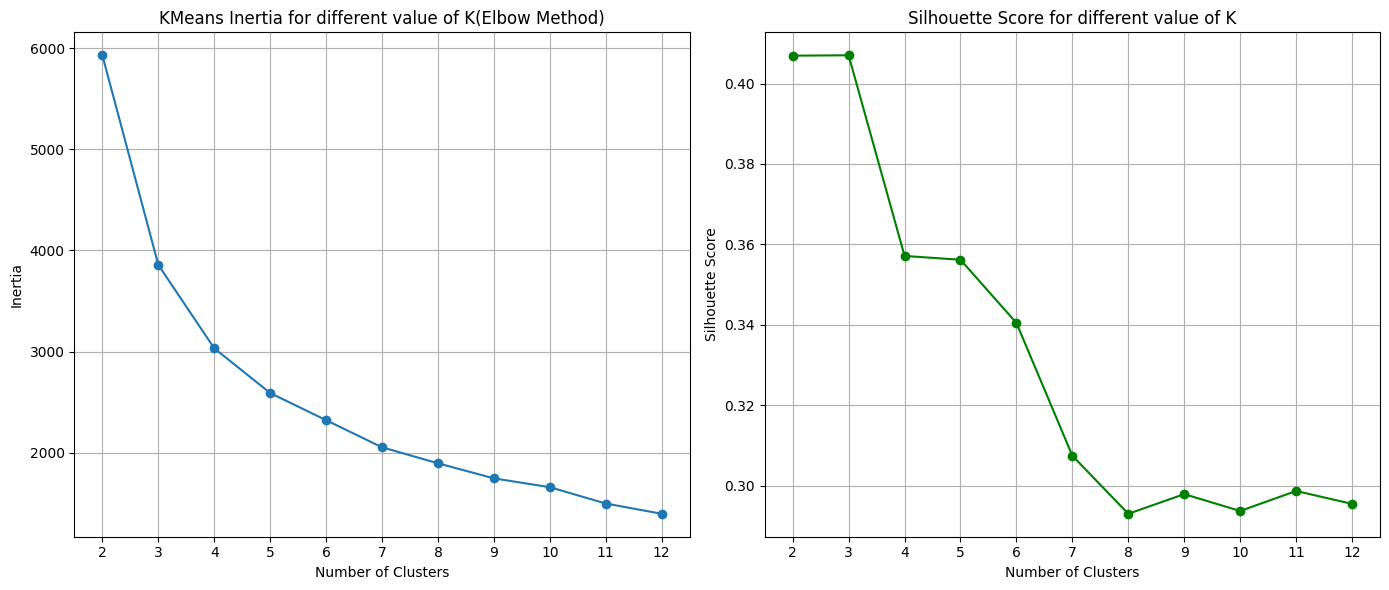

In [142]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
max_k=12 #big number of cluseter(assume)

inertia=[]
silhoutte_scores=[]
k_values=range(2,max_k+1) #max_k+1:cause last value is exclusive in range()

for k in k_values:
    k_means=KMeans(n_clusters=k,random_state=42,max_iter=1000)

    cluster_labels=k_means.fit_predict(scaled_df)

    sil_score=silhouette_score(scaled_df,cluster_labels)
    silhoutte_scores.append(sil_score)

    inertia.append(k_means.inertia_)


# visualization
# Inertia KMeans
plt.figure(figsize=(14,6))


plt.subplot(1,2,1)
plt.plot(k_values,inertia,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.title('KMeans Inertia for different value of K(Elbow Method)')
plt.grid(True)

# Silhotte score
plt.subplot(1,2,2)
plt.plot(k_values,silhoutte_scores,marker='o',color='green')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.title('Silhouette Score for different value of K')
plt.grid(True)

plt.tight_layout()
plt.show()

### Silhouette Score

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

Where:
- $s(i)$ is the silhouette score for a single sample $i$
- $a(i)$ is the average distance between $i$ and all other points in the same cluster,
- $b(i)$ is the minimum average distance between $i$ and all points in the nearest cluster to which $i$ does not belong.

The silhoutte score ranges between $[-1, 1]$, a higher value indicates more distinct clusters.

__Insights__
This Chart clearly implying ,__K=3__ will be accurate cluster.

__1. Left Graph: KMeans Inertia (The Elbow Method)__

This chart shows how compact your clusters are. Lower inertia means data points are closer to their cluster centers.
* **The Goal:** Look for the "elbow" point where the sharp drop slows down and turns into a gradual slope.
* **Interpretation:** There is a massive drop from \(K=2\) to \(K=3\). After \(K=3\) (or \(K=4\)), the curve flattens significantly. This indicates that adding more clusters beyond 3 or 4 gives diminishing returns in explaining data variance.

__2. Right Graph: Silhouette Score__

This chart measures how well-separated the clusters are. It evaluates if a customer truly belongs to their assigned group compared to the next closest group.
* **The Goal:** Look for the highest peak. A higher score means better-defined, distinct clusters with less overlap.
* **Interpretation**: The score peaks clearly at \(K=3\) (around 0.46). After \(K=3\), the score drops sharply, meaning adding more groups will make your customer segments overlap and become blurry.

At high score clearly visible cluster ,if there is lower silhouette score (mean overlap cluster)

 __\(K = 3\) is your magic number__

In [143]:
inertia

[5929.197863013278,
 3857.188966434245,
 3032.5269200819193,
 2590.230295832137,
 2321.7208489321883,
 2053.626578378434,
 1895.4818161607218,
 1746.6174300721534,
 1659.2231776591766,
 1498.0375454028112,
 1396.3903347215285]

In [144]:
silhoutte_scores

[np.float64(0.40692537752042696),
 np.float64(0.4070257948311317),
 np.float64(0.3571066100540752),
 np.float64(0.35615914573102253),
 np.float64(0.3404532250805066),
 np.float64(0.30740719416640855),
 np.float64(0.29296486572000824),
 np.float64(0.29786048366182816),
 np.float64(0.2936626273860342),
 np.float64(0.29863800627052156),
 np.float64(0.29543317788816115)]

Choosing k=3 ,& assigning cluster to data points

In [145]:
kmeans=KMeans(n_clusters=3,random_state=42,max_iter=1000)   
cluster_labels=kmeans.fit_predict(scaled_df)
cluster_labels

array([2, 1, 0, ..., 2, 1, 1], dtype=int32)

saving model in artifacts

In [146]:
import joblib
# 1. Define your specific folder location
output_dir = "./artifacts"
os.makedirs(output_dir, exist_ok=True)  # Creates folder if it does not exist

# 2. Build the full file path
file_path = os.path.join(output_dir, "kmeans.joblib")
# 3. Saving the Scaler
joblib.dump(kmeans,file_path)

['./artifacts\\kmeans.joblib']

In [147]:
non_outlier_df['Cluster']=cluster_labels

C:\Users\MANN\AppData\Local\Temp\ipykernel_8468\3044991670.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outlier_df['Cluster']=cluster_labels


In [148]:
non_outlier_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,MonetaryValue_lg,Frequency_lg,Cluster
0,12346.0,169.36,2,2010-06-28 13:53:00,164,5.137914,1.098612,2
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,7.188654,1.098612,1
2,12348.0,221.16,1,2010-09-27 14:59:00,73,5.403398,0.693147,0
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,7.706226,1.098612,1
4,12352.0,343.80,2,2010-11-29 10:07:00,10,5.842965,1.098612,0
...,...,...,...,...,...,...,...,...
4262,18283.0,619.37,6,2010-11-22 15:30:00,17,6.430316,1.945910,1
4263,18284.0,411.68,1,2010-10-04 11:33:00,66,6.022672,0.693147,0
4264,18285.0,377.00,1,2010-02-17 10:24:00,295,5.934894,0.693147,2
4265,18286.0,1246.43,2,2010-08-20 11:57:00,111,7.128841,1.098612,1


3 Cluster={0,1,2}


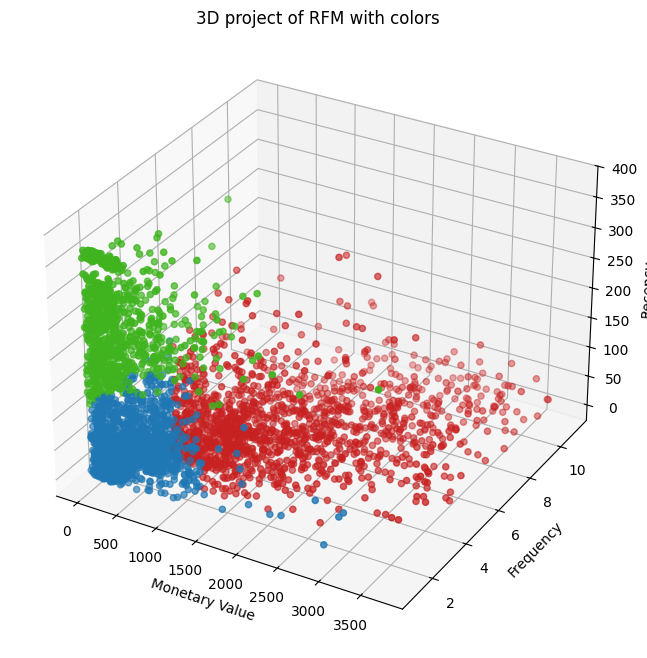

In [149]:
# assigning cluster  to CLusters
cluster_color={0:'#1f77b4',
               1:"#c82121",
               2:"#3fb41f"
               }
colors=non_outlier_df['Cluster'].map(cluster_color)
fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(projection='3d')
scatter=ax.scatter(non_outlier_df['MonetaryValue'],
                   non_outlier_df['Frequency'],
                   non_outlier_df['Recency'],
                   c=colors,
                   marker='o')
ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D project of RFM with colors')
plt.show()

K-Means successfully separated your customers into three distinct, logical business groups based on their behavior.

* **Blue(VIP CUSTOMER(consistent)):** High Monetary(>500),High Frequency(>4),Low Recency
* **Red(ACTIVE/NEW CUSTOMER):** Less monetary(<500),less Frequency(4-6),Less Recency(below 100)
* **Green(Inconsisten/At RISK):** Less Monetary(<500),average frequency(6-8),high Recency(3months <13 months)

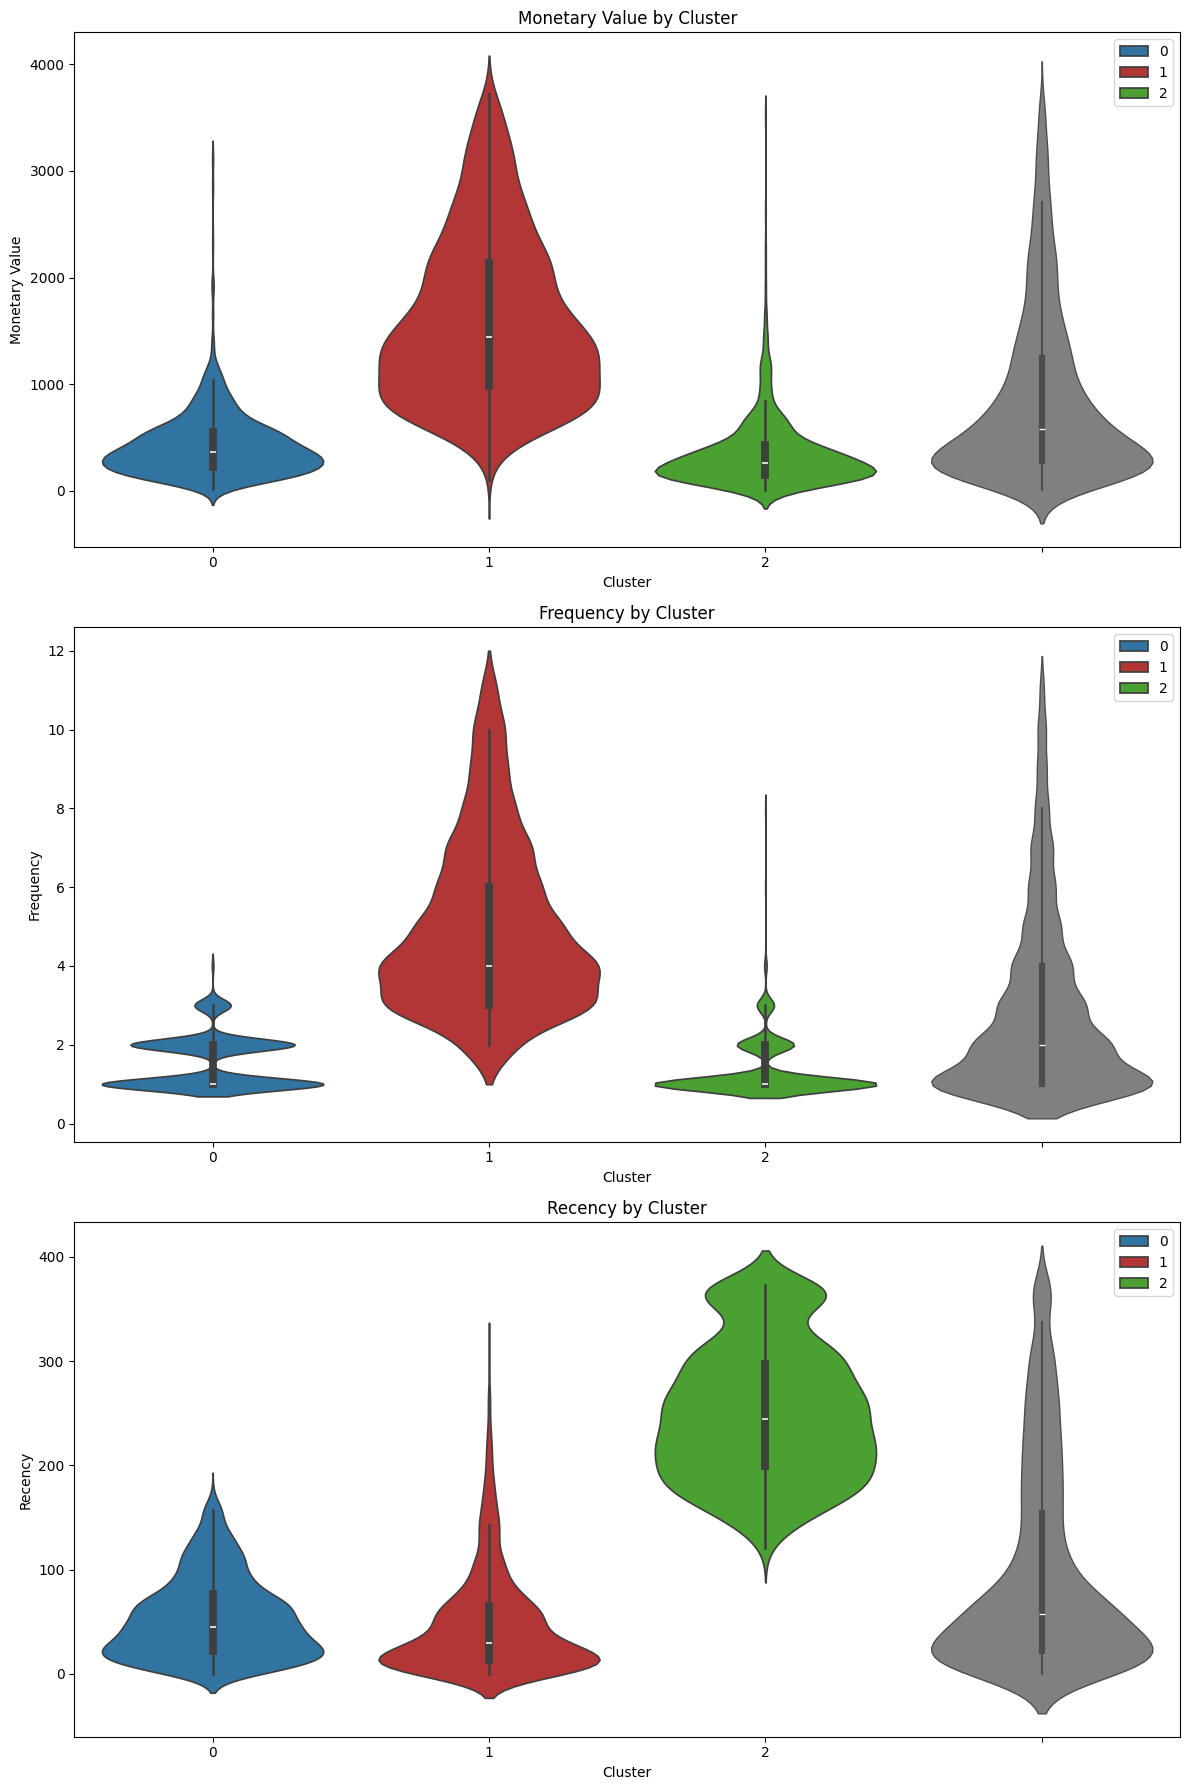

In [150]:
plt.figure(figsize=(12,18))

plt.subplot(3,1,1)
sns.violinplot(x=non_outlier_df['Cluster'],y=non_outlier_df['MonetaryValue'],palette=cluster_color,hue=non_outlier_df['Cluster'])
sns.violinplot(y=non_outlier_df['MonetaryValue'],color='gray',linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')


plt.subplot(3,1,2)
sns.violinplot(x=non_outlier_df['Cluster'],y=non_outlier_df['Frequency'],palette=cluster_color,hue=non_outlier_df['Cluster'])
sns.violinplot(y=non_outlier_df['Frequency'],color='gray',linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3,1,3)
sns.violinplot(x=non_outlier_df['Cluster'],y=non_outlier_df['Recency'],palette=cluster_color,hue=non_outlier_df['Cluster'])
sns.violinplot(y=non_outlier_df['Recency'],color='gray',linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

__High Spender__: Vast majority soend higher
* **BLue(VIP(Big Spender)/Regular)**:(Low  Rcncy,6-8 Frequency,High Monetary) 

__Low Spender__:Vast Majority Spend low

* **Red(NEW CUSTOMER/Active):** (Low Monetary($350),low Frequency,low Recency)
* **Green(The Ghoster/LOST/Churned):** (Low Monetary Value(less than Red),low FREQUENCY(AS frequency increase,Distribution decreases),high Recency(Around Year))

The grey violin on the right represents your entire, unsegmented dataset combined (all customers before K-Means grouping).


You need it because it serves as your baseline benchmark. Without it, you cannot easily prove whether your clustering actually discovered unique customer behaviors.

__Summary__:
* **Cluster(0)**:VIP/Champion
* **Cluster(2)**:New customer/Low Value Active Customer
* **Cluster(1)**:Lost/The Ghoster/Churned 

In [151]:
non_outlier_df['Cluster'].value_counts()

Cluster
1    1486
0    1430
2     882
Name: count, dtype: int64

**Outlier Data Frame:** We had already removed,now we're gonna creating new outlier dataFrame,where it'll be having (Frequency,Monetary,Frequency+Monetary Outliers) in a single data Frame .So that later Segmented Customer could also be founded from Outlier dataset.

In [152]:
overlap_indices=monetary_outliers_df.index.intersection(frequency_outliers.index)

# seperating OUTLIERS INTO 3 CATEGORIES
monetary_only_outliers=monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers=frequency_outliers.drop(overlap_indices)
monetary_frequency_outliers=monetary_outliers_df.loc[overlap_indices]

# Assigning cluster
monetary_only_outliers['Cluster']= -1 #Monetary
frequency_only_outliers['Cluster']= -2 #Frequency
monetary_frequency_outliers['Cluster']= -3 #OVerlap

outlier_cluster_df=pd.concat([monetary_only_outliers,frequency_only_outliers,monetary_frequency_outliers])
outlier_cluster_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
8,12357.0,11229.99,1,2010-11-16 10:05:00,23,-1
24,12380.0,4782.84,4,2010-08-31 14:54:00,100,-1
41,12409.0,12346.62,4,2010-10-15 10:24:00,55,-1
47,12415.0,19131.24,4,2010-11-29 15:07:00,10,-1
60,12431.0,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4218,18225.0,7539.84,15,2010-12-09 15:46:00,0,-3
4219,18226.0,6324.43,15,2010-11-26 15:51:00,13,-3
4223,18231.0,4776.50,23,2010-10-29 14:17:00,41,-3
4232,18245.0,3757.92,13,2010-11-25 16:52:00,14,-3


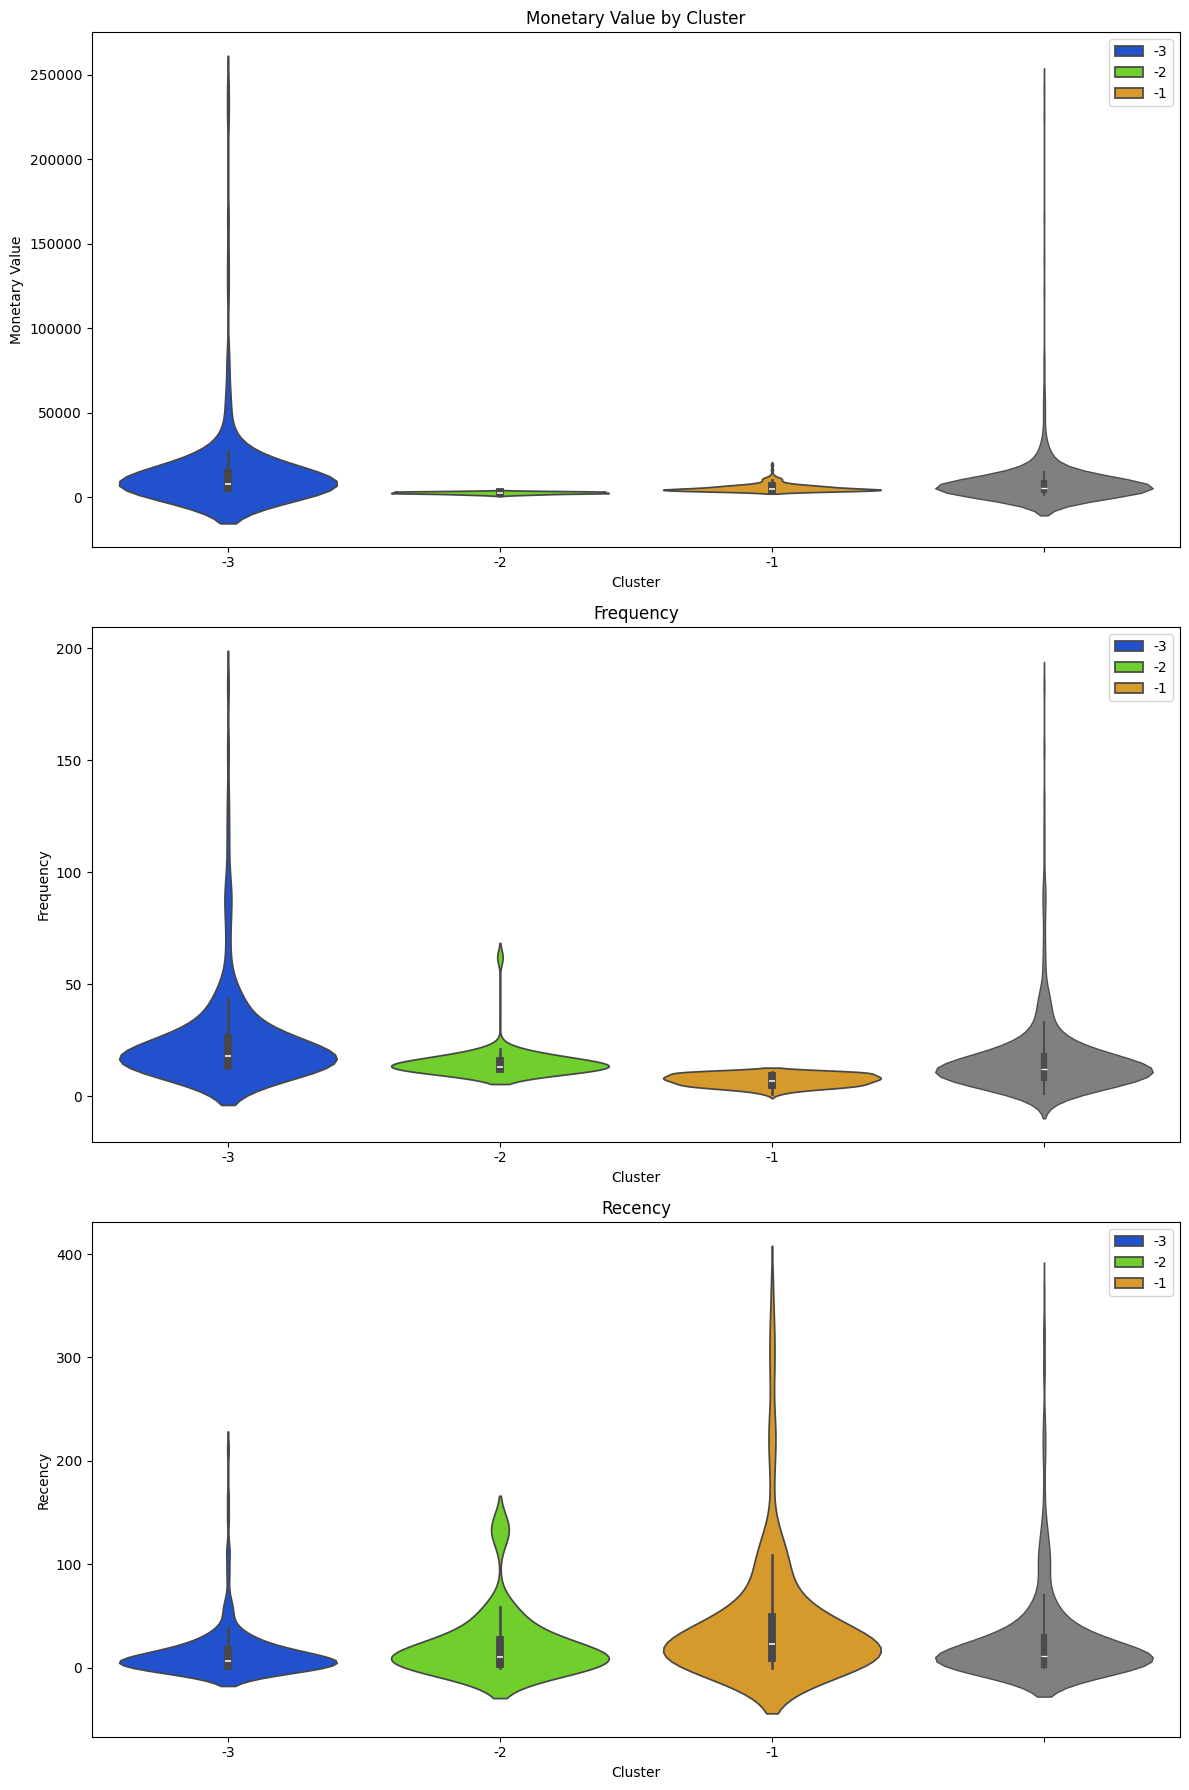

In [153]:
cluster_color={-1: "#f2a20e",
               -2:"#6ce912fd",
               -3:"#0445e9"
               }

plt.figure(figsize=(12,18))

plt.subplot(3,1,1)
sns.violinplot(x=outlier_cluster_df['Cluster'],y=outlier_cluster_df['MonetaryValue'],palette=cluster_color,hue=outlier_cluster_df['Cluster'])
sns.violinplot(y=outlier_cluster_df['MonetaryValue'],color='gray',linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3,1,2)
sns.violinplot(x=outlier_cluster_df['Cluster'],y=outlier_cluster_df['Frequency'],palette=cluster_color,hue=outlier_cluster_df['Cluster'])
sns.violinplot(y=outlier_cluster_df['Frequency'],color='gray',linewidth=1.0)
plt.title('Frequency')


plt.subplot(3,1,3)
sns.violinplot(x=outlier_cluster_df['Cluster'],y=outlier_cluster_df['Recency'],palette=cluster_color,hue=outlier_cluster_df['Cluster'])
sns.violinplot(y=outlier_cluster_df['Recency'],color='gray',linewidth=1.0)
plt.title('Recency')


plt.tight_layout()
plt.show()

__Insights:__
* **Cluster -1(Monetary Value OUTLIER):** Moderate High Monetary($22,000) , High Frequency(12), Extreme high Recency(1 yr).<br>
These are Whale Customers(**Big Spender At Risk/Huge Spender Customer**),they may be Churned. You really need to pull them back.<br>
**Action:**Welcome Back Discount , new Varities items introduce.Email :miss you shopping

* **Cluster -2(Frequency OUTLIER):** Extreme Low Monetary($5000) , Hight Frequency(70),High recency(6mnths)<br>
These are **Systematic shopper/low spender customer**, but they're **Frequent**.They're inactive customers(2 Density width) means recency increases.
<br>
**Action:** Provide ** Attractive Discount**,**Combo Offer**,**free coupon** for motiating them to shop here.

* **Cluster -3(Monetary & Frequency OUTLIER):** Extreme high($250,000),Extreme High(200), High Recency(7-8 months)<br>
This proves that the extreme outliers in your entire business dataset are being driven completely by Cluster -3. Cluster -3 is pulling the global average upward all by itself.<br>
They're **Whale/Enterprise/VIP Clients/Gaint spender** with **huge bulk frequency** but Recency is extremely high.They can give you extreme **Profit**,we should pull them back<br>
**Action:** Free Passes for Sports Matches,Premium Membership

In [154]:
outlier_cluster_df['Frequency'].agg(max)

C:\Users\MANN\AppData\Local\Temp\ipykernel_8468\2893107720.py:1: FutureWarning: The provided callable <built-in function max> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  outlier_cluster_df['Frequency'].agg(max)


np.int64(183)

__Mapping CLuster__:

So I've analyzed/study the both Violin Graphs.I could get to know ,which cluster is holding what kind of customer behavior.Now I have proper insights about every cluster.Now we're gonna Map those **cluster** with those **Cluster labels**

In [155]:
cluster_labels_mapping={
    0:'New/Recent Customers', #new
    1:'VIPs,Champions', #champion /vip
    2:'Lost/Churned Customers',#lost
    -1:'Hibernating / Risk of Churn',
    -2:'Loyal Everyday Shoppers',
    -3:'Enterprise / VIP Whales'
}

# cluster_labels_mapping={
#     0:'Champions/VIPs', #new
#     1:'At-Risk / Lost Customers', #champion /vip
#     2:'New / Promising Customers',#lost
#     -1:'Hibernating / Risk of Churn',
#     -2:'Loyal Everyday Shoppers',
#     -3:'Enterprise / VIP Whales'
# }

In [156]:
all_cluster_df=pd.concat([non_outlier_df,outlier_cluster_df])
print('All Cluster Dataset: \n',all_cluster_df.head())
print('Cluster Value Counts: \n',all_cluster_df['Cluster'].value_counts())

All Cluster Dataset: 
    Customer ID  MonetaryValue  Frequency     LastInvoiceDate  Recency  \
0      12346.0         169.36          2 2010-06-28 13:53:00      164   
1      12347.0        1323.32          2 2010-12-07 14:57:00        2   
2      12348.0         221.16          1 2010-09-27 14:59:00       73   
3      12349.0        2221.14          2 2010-10-28 08:23:00       42   
4      12352.0         343.80          2 2010-11-29 10:07:00       10   

   MonetaryValue_lg  Frequency_lg  Cluster  
0          5.137914      1.098612        2  
1          7.188654      1.098612        1  
2          5.403398      0.693147        0  
3          7.706226      1.098612        1  
4          5.842965      1.098612        0  
Cluster Value Counts: 
 Cluster
 1    1486
 0    1430
 2     882
-3     223
-1     195
-2      51
Name: count, dtype: int64


In [157]:
all_cluster_df['ClusterLabel']=all_cluster_df['Cluster'].map(cluster_labels_mapping)
print('All CLuster data with Cluster label: \n',all_cluster_df.head())
print('Cluster Labels with Frequency:\n',all_cluster_df['ClusterLabel'].value_counts())

All CLuster data with Cluster label: 
    Customer ID  MonetaryValue  Frequency     LastInvoiceDate  Recency  \
0      12346.0         169.36          2 2010-06-28 13:53:00      164   
1      12347.0        1323.32          2 2010-12-07 14:57:00        2   
2      12348.0         221.16          1 2010-09-27 14:59:00       73   
3      12349.0        2221.14          2 2010-10-28 08:23:00       42   
4      12352.0         343.80          2 2010-11-29 10:07:00       10   

   MonetaryValue_lg  Frequency_lg  Cluster            ClusterLabel  
0          5.137914      1.098612        2  Lost/Churned Customers  
1          7.188654      1.098612        1          VIPs,Champions  
2          5.403398      0.693147        0    New/Recent Customers  
3          7.706226      1.098612        1          VIPs,Champions  
4          5.842965      1.098612        0    New/Recent Customers  
Cluster Labels with Frequency:
 ClusterLabel
VIPs,Champions                 1486
New/Recent Customers       

## Visualization: Customer Volume & Customer Behaviors

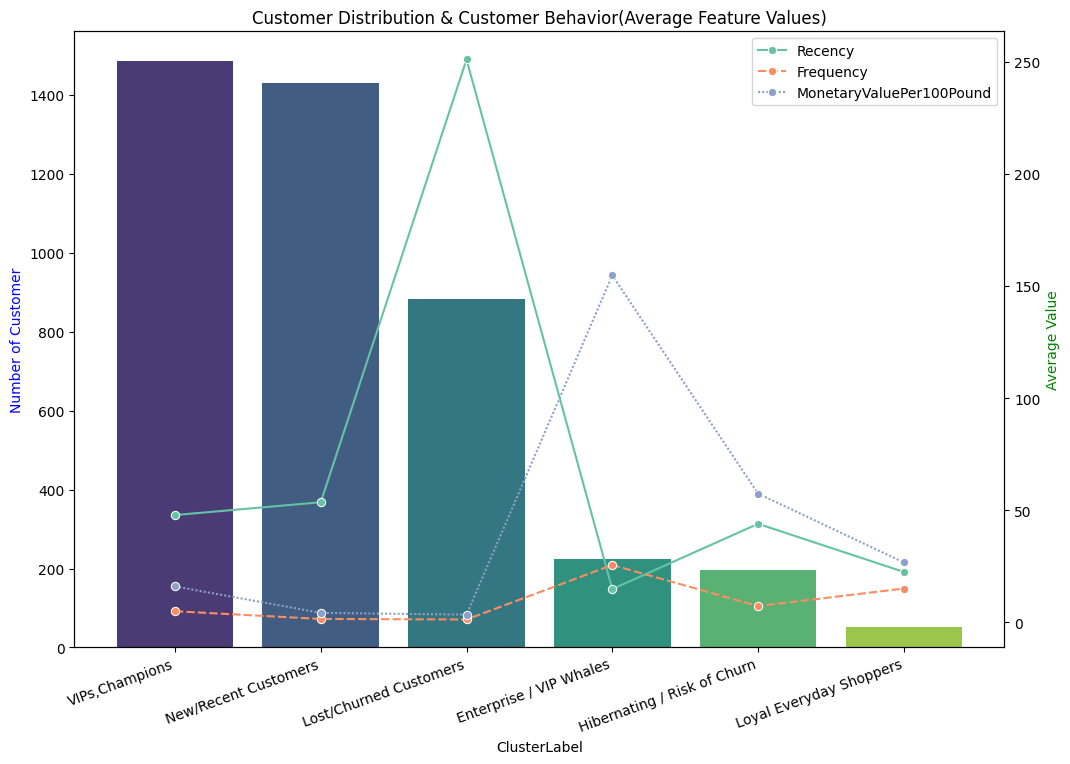

In [158]:
cluster_counts=all_cluster_df['ClusterLabel'].value_counts()
all_cluster_df['MonetaryValuePer100Pound']=all_cluster_df['MonetaryValue']/100.00

feature_means=all_cluster_df.groupby('ClusterLabel')[['Recency','Frequency','MonetaryValuePer100Pound']].mean()

fig,ax1=plt.subplots(figsize=(12,8))

sns.barplot(x=cluster_counts.index,y=cluster_counts.values,ax=ax1,palette='viridis',hue=cluster_counts.index)
ax1.set_ylabel('Number of Customer',color='b')
ax1.set_title('Customer Distribution & Customer Behavior(Average Feature Values)')
plt.xticks(rotation=20,ha='right')

ax2=ax1.twinx()
sns.lineplot(data=feature_means,ax=ax2,palette='Set2',marker='o')
ax2.set_ylabel('Average Value',color='g')

plt.show()

#### __Customer Distribution & RFM Behavior Analysis__
This dual-axis chart provides a macro-level view of our customer segmentation strategy. The bar chart (left y-axis) represents the **total volume of customers** within each cluster, while the line plots (right y-axis) illustrate the **average** Recency, Frequency, and scaled Monetary Value for those respective groups.

__Deep Cluster Behaviors__

**1.Champions/VIPs:**
* Behavior: Strong performance across all three metrics. They purchase frequently, have shopped recently, and maintain a healthy average spend.
* Significance: This is the bedrock of the revenue stream.

**2.New / Promising Customers:**
* Behavior: Very low Recency (recent shoppers) but low Frequency and Monetary value.
* Significance: They have successfully made their first or second purchase. The immediate business goal here is habit-formation to move them into the Champions tier.

**3.At-Risk / Lost Customers:**
* Behavior: The defining feature of this group is the extreme spike in the Recency line (peaking near 250+ on the right axis). Frequency and Monetary values are flat at the bottom.
* Significance: These customers have churned. Re-acquisition costs will likely be high, and marketing spend here should be carefully capped.

**4.Enterprise / VIP Whales:**
* Behavior: A massive upward spike in the Monetary Value line (scaled per £100), combined with the highest average Frequency and near-zero Recency.
* Significance: High-value B2B or wholesale clients. Losing even one of these customers would result in a noticeable revenue hit.

**5.Hibernating / Risk of Churn:**
* Behavior: Moderate Recency with a noticeable bump in historical Monetary value compared to everyday shoppers.
* Significance: They used to spend good money but are currently extending their time between purchases. They require immediate, targeted re-engagement before they cross over into the "Lost" category.

**6.Loyal Everyday Shoppers:**
* Behavior: The smallest segment by volume. They have very low Recency and decent Frequency, but their Monetary value remains low.
* Significance: Highly engaged but price-conscious. They visit often but buy cheap items. Excellent targets for cross-selling or volume-based discounts.

In [159]:
feature_means

,Recency,Frequency,MonetaryValuePer100Pound
ClusterLabel,,,
Enterprise / VIP Whales,14.901345,25.627803,154.770163
Hibernating / Risk of Churn,43.984615,7.307692,57.448790
Lost/Churned Customers,250.967120,1.340136,3.485004
Loyal Everyday Shoppers,22.549020,15.137255,26.758994
New/Recent Customers,53.599301,1.568531,4.296408
"VIPs,Champions",47.884253,5.020188,16.070214


In [160]:
# earlier version
aggregated_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12352.0,343.80,2,2010-11-29 10:07:00,10
...,...,...,...,...,...
4262,18283.0,619.37,6,2010-11-22 15:30:00,17
4263,18284.0,411.68,1,2010-10-04 11:33:00,66
4264,18285.0,377.00,1,2010-02-17 10:24:00,295
4265,18286.0,1246.43,2,2010-08-20 11:57:00,111


In [161]:
# current version
all_cluster_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,MonetaryValue_lg,Frequency_lg,Cluster,ClusterLabel,MonetaryValuePer100Pound
0,12346.0,169.36,2,2010-06-28 13:53:00,164,5.137914,1.098612,2,Lost/Churned Customers,1.6936
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,7.188654,1.098612,1,"VIPs,Champions",13.2332
2,12348.0,221.16,1,2010-09-27 14:59:00,73,5.403398,0.693147,0,New/Recent Customers,2.2116
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,7.706226,1.098612,1,"VIPs,Champions",22.2114
4,12352.0,343.80,2,2010-11-29 10:07:00,10,5.842965,1.098612,0,New/Recent Customers,3.4380


**Doubt**: Who really are New Customers ->__Investigating New Customers(Cluster 2)__
* Who are really New(Under 2 months) &  New Old Customers(Above 2 months)
* Their Frequency new & New Old Customers

In [162]:
all_cluster_df[all_cluster_df['Cluster']==2]['Frequency'].value_counts()

Frequency
1    656
2    167
3     50
4      7
6      1
8      1
Name: count, dtype: int64

In [163]:
all_cluster_df[(all_cluster_df['Cluster']==2) & ( all_cluster_df['Recency']<53) ]['Frequency'].value_counts()

Series([], Name: count, dtype: int64)

In [164]:
all_cluster_df[(all_cluster_df['Cluster']==2) & ( all_cluster_df['Recency']>53)]['Frequency'].value_counts()


Frequency
1    656
2    167
3     50
4      7
6      1
8      1
Name: count, dtype: int64

Text(0.5, 1.0, 'CLuster 2 days')

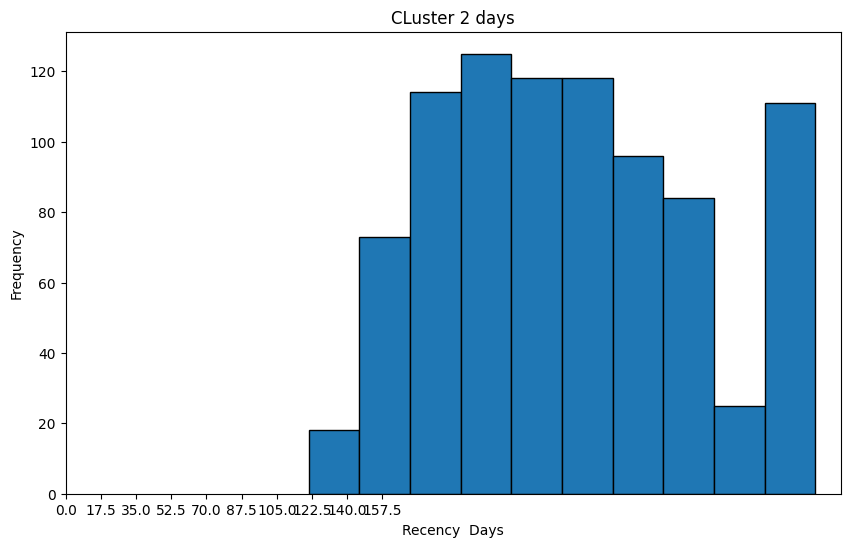

In [165]:
all_cluster_df[all_cluster_df['Cluster']==2]['Recency'].plot(kind='hist',figsize=(10,6),edgecolor='black')
plt.xlabel('Recency  Days')
plt.xticks(np.arange(0,175,17.5))
plt.title('CLuster 2 days')

__Insights:__
2 Things are pretty clear from this histogram in **Cluster 2**
* **Under 53 Days**:max new Customers assume 
* **Above 53 Days**:Old new Custoemrs

Both had similar kind of Value Counts

In [166]:
all_cluster_df[all_cluster_df['Cluster']==2]['Recency'].describe()

count    882.000000
mean     250.967120
std       64.286285
min      121.000000
25%      199.000000
50%      245.000000
75%      297.000000
max      373.000000
Name: Recency, dtype: float64

**Customer Distribution by Segment (Clusters) over Pie Chart**

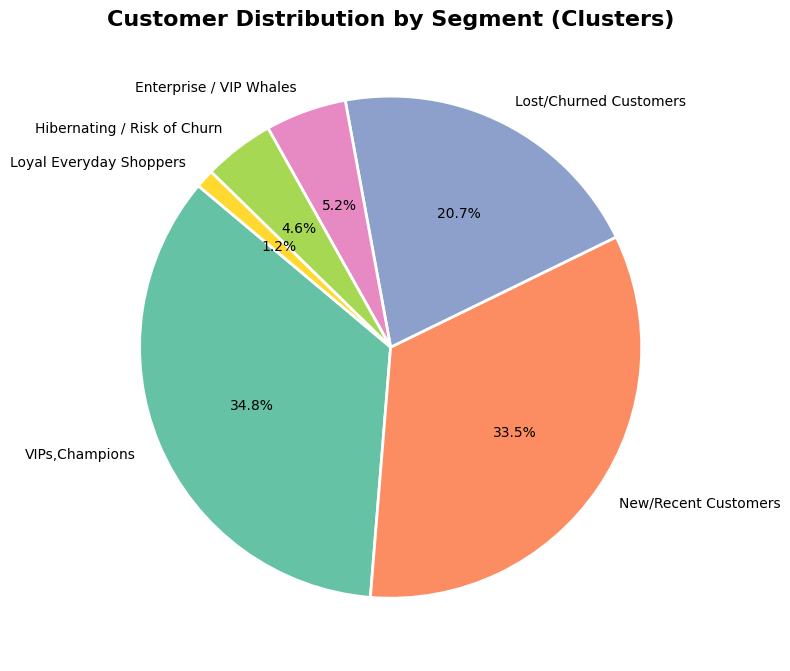

In [167]:
cluster_counts=all_cluster_df['ClusterLabel'].value_counts()

plt.figure(figsize=(8,8))
colors = sns.color_palette('Set2', len(cluster_counts))

plt.pie(
    cluster_counts, 
    labels=cluster_counts.index,   # Label each slice with the cluster name/ID
    autopct='%1.1f%%',            # Display the percentage format on the slice
    startangle=140,                # Rotate the start for a cleaner look
    colors=colors,                 # Match the colors with your scatter plot
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  # Adds crisp white borders
)
plt.title('Customer Distribution by Segment (Clusters)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

__Insights:__
* **Major Portion** is covered by *Champions/VIPs , At-Risk / Lost Customers , At-Risk / Lost Customers* 
* **Minor Portion** is covered by *Enterprise / VIP Whales , Hibernating / Risk of Churn , Loyal Everyday Shoppers*

## __Conclustion__

#### __Customer Segmentation Insights & Strategic Actions__

__1. Champions / VIPs (Cluster 0)__

**Insights:** This segment constitutes the largest portion of the customer base. They exhibit strong metrics across the board: very low recency, high frequency, and solid monetary value. They are highly engaged and represent the core revenue engine.

**Actions:**
* Implement loyalty and VIP reward programs.
* Offer exclusive early access to new product launches.
* Leverage them for referrals, testimonials, and beta-testing new features.

__2. At-Risk / Lost Customers (Cluster 1)__

**Insights:** Characterized by an extreme spike in recency (often 200 to 300+ days since the last purchase), alongside the lowest frequency and monetary values. These customers have effectively churned.

**Actions:**
* Deploy aggressive win-back campaigns with steep, one-time discounts.
* Send targeted "We miss you" automated communications.
* If reactivation fails, remove them from high-cost paid marketing funnels to optimize advertising ROI.

__3. New / Promising Customers (Cluster 2)__

**Insights:** These customers have very low recency, indicating they have interacted with the business recently. However, their frequency is concentrated around 1 to 2 purchases, and their overall monetary value remains low. They are in the exploratory phase.This cluster includes both genuinely new and one-time lapsed customers in roughly equal measure.
**Actions:**
* Trigger automated onboarding and welcome email sequences.
* Provide incentives on their second purchase to build a purchasing habit.
* Highlight top-selling products and cross-category items to drive discovery.

__4. Hibernating / Risk of Churn (Cluster -1)__

**Insights:** The violin plots show a long, stretching tail for recency, indicating these previously active customers are extending the time between their orders. They possess decent historical frequency and monetary value but are actively slipping away.

**Actions:**
* Utilize personalized product recommendations based on their historical purchase data.
* Offer time-sensitive discounts to create immediate urgency.
* Reach out via feedback surveys to understand potential dissatisfaction or shifts in needs.

__5. Loyal Everyday Shoppers (Cluster -2)__

**Insights:** This group displays a very tight, low monetary value distribution coupled with high frequency and low recency. They interact continuously but spend minimal amounts per transaction.

**Actions:**
* Focus heavily on upselling and cross-selling to increase Average Order Value (AOV).
* Implement minimum spend thresholds for perks (e.g., free shipping over a specific cart value).
* Offer volume-based discounts or product bundling.

__6. Enterprise / VIP Whales (Cluster -3)__

**Insights:** The smallest demographic by volume but responsible for extreme outliers in the data. Monetary values reach massive peaks, and frequency is remarkably high with near-zero recency. These represent major B2B accounts, wholesalers, or enterprise clients.

**Actions:**
* Assign dedicated account managers to provide white-glove, personalized service.
* Create bespoke pricing tiers, bulk-order portals, or specialized wholesale contracts.
* Establish direct communication channels to ensure high-level retention and operational alignment.

**Final Data Frame Export:**
Below is the final data set of every single Customer  with RFM , cluster & cluster labels. You can export this dataset for further actions.

In [168]:
all_cluster_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,MonetaryValue_lg,Frequency_lg,Cluster,ClusterLabel,MonetaryValuePer100Pound
0,12346.0,169.36,2,2010-06-28 13:53:00,164,5.137914,1.098612,2,Lost/Churned Customers,1.6936
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,7.188654,1.098612,1,"VIPs,Champions",13.2332
2,12348.0,221.16,1,2010-09-27 14:59:00,73,5.403398,0.693147,0,New/Recent Customers,2.2116
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,7.706226,1.098612,1,"VIPs,Champions",22.2114
4,12352.0,343.80,2,2010-11-29 10:07:00,10,5.842965,1.098612,0,New/Recent Customers,3.4380
...,...,...,...,...,...,...,...,...,...,...
4218,18225.0,7539.84,15,2010-12-09 15:46:00,0,NaN,NaN,-3,Enterprise / VIP Whales,75.3984
4219,18226.0,6324.43,15,2010-11-26 15:51:00,13,NaN,NaN,-3,Enterprise / VIP Whales,63.2443
4223,18231.0,4776.50,23,2010-10-29 14:17:00,41,NaN,NaN,-3,Enterprise / VIP Whales,47.7650
4232,18245.0,3757.92,13,2010-11-25 16:52:00,14,NaN,NaN,-3,Enterprise / VIP Whales,37.5792


In [ ]:
# Exporting in CSV format
# all_cluster_df.to_csv(r'e:\dsProject\customerSegmentation\data\rfm_Customer_cluster.csv',index=False)

In [ ]:
# Exporting Clean Customer Retail data
# df_clean.to_csv(r'e:\dsProject\customerSegmentation\data\clean_Customer_Retail.csv',index=False)

RFM segmentation helps to distinguish where your revenue comes from and which customers are your core audience. By segmenting your customer base according to the RFM factors (Recency, Frequency, Monetary), you’ll get a holistic overview, which allows for better targeting of campaigns at customers based on how loyal they are to the brand and hence increase upsell, RVP and other essential metrics.

RFM analysis helps bank marketers and management find answers to the following questions:

Who are our best customers?
Which customer segments drive our churn rate?
Which bank customer has the potential to be in the top quartile of lifetime profitability?
Which of your customer segments should we market to help stem defections?
Which customers should receive deposit rate increases to keep them from defecting?
What rate should we pay a deposit customer at risk of defecting?
Which of your customers are most likely to respond to an engagement or promotional campaign?

In [178]:
df_clean

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum,hours,weeks,month
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,7,1,12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,7,1,12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,7,1,12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,7,1,12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,7,1,12
...,...,...,...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90,20,3,12
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,20,3,12
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,20,3,12
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50,20,3,12
